In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

import plotly.express as px
import plotly.io as pio
from kaleido.scopes.plotly import PlotlyScope

import mygene

Fig - 1.A (CIBERSORT Website)

Fig - 1.B 

Fig - 1.C (Giavarina Plot)

In [22]:
df = pd.read_csv("Data/Figure_Data/Stem_cell_validation.csv", index_col=(0))
df = df[['stem', 'actual']]

In [24]:


means = df.mean(axis=1)
diffs = df.diff(axis=1).iloc[:, -1]
percent_diffs = diffs / means * 100
bias = np.mean(percent_diffs)
sd = np.std(percent_diffs, ddof=1)
upper_loa = bias + 1.96 * sd
lower_loa = bias - 1.96 * sd

# Sample size
n = df.shape[0]
# Variance
var = sd**2
# Standard error of the bias
se_bias = np.sqrt(var / n)
# Standard error of the limits of agreement
se_loas = np.sqrt(3 * var / n)
# Endpoints of the range that contains 95% of the Student’s t distribution
t_interval = stats.t.interval(confidence=0.95, df=n - 1)
# Confidence intervals

ci_bias = bias + np.array(t_interval) * se_bias
ci_upperloa = upper_loa + np.array(t_interval) * se_loas
ci_lowerloa = lower_loa + np.array(t_interval) * se_loas

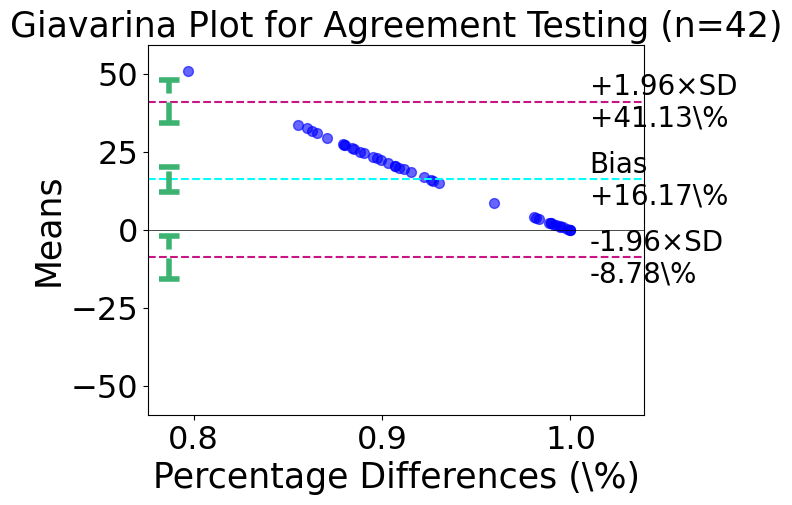

In [25]:
ax = plt.axes()
ax.set(
    title='Giavarina Plot for Two Hypothetical Measurement Methods',
    xlabel='Means', ylabel=r'Percentage Differences (\%)'
)
# Scatter plot
ax.scatter(means, percent_diffs, c='b', s=50, alpha=0.6, marker='o')
# Plot the zero line
ax.axhline(y=0, c='k', lw=0.5)
# Plot the bias and the limits of agreement
ax.axhline(y=upper_loa, c='mediumvioletred', ls='--')
ax.axhline(y=bias, c='cyan', ls='--')
ax.axhline(y=lower_loa, c='mediumvioletred', ls='--')
# Get axis limits
left, right = plt.xlim()
bottom, top = plt.ylim()
# Increase the y-axis limits to create space for the confidence intervals
max_y = max(abs(ci_lowerloa[0]), abs(ci_upperloa[1]), abs(bottom), abs(top))
ax.set_ylim(-max_y * 1.1, max_y * 1.1)
# Set x-axis limits
domain = right - left
ax.set_xlim(left - domain * 0.05, left + domain * 1.13)
# Add the annotations
ax.annotate('+1.96×SD', (right, upper_loa), xytext=(0, 7), textcoords='offset pixels', fontsize=20)
ax.annotate(fr'{upper_loa:+4.2f}\%', (right, upper_loa), xytext=(0, -25), textcoords='offset pixels', fontsize=20)
ax.annotate('Bias', (right, bias), xytext=(0, 7), textcoords='offset pixels', fontsize=20)
ax.annotate(fr'{bias:+4.2f}\%', (right, bias), xytext=(0, -25), textcoords='offset pixels', fontsize=20)
ax.annotate('-1.96×SD', (right, lower_loa), xytext=(0, 7), textcoords='offset pixels', fontsize=20)
ax.annotate(fr'{lower_loa:+4.2f}\%', (right, lower_loa), xytext=(0, -25), textcoords='offset pixels', fontsize=20)
# Plot the confidence intervals
ax.plot([left] * 2, list(ci_upperloa), c='mediumseagreen', ls='--', linewidth=4)
ax.plot([left] * 2, list(ci_bias), c='mediumseagreen', ls='--', linewidth=4)
ax.plot([left] * 2, list(ci_lowerloa), c='mediumseagreen', ls='--', linewidth=4)
# Plot the confidence intervals' caps
x_range = [left - domain * 0.025, left + domain * 0.025]
ax.plot(x_range, [ci_upperloa[1]] * 2, c='mediumseagreen', ls='--', linewidth=4)
ax.plot(x_range, [ci_upperloa[0]] * 2, c='mediumseagreen', ls='--', linewidth=4)
ax.plot(x_range, [ci_bias[1]] * 2, c='mediumseagreen', ls='--', linewidth=4)
ax.plot(x_range, [ci_bias[0]] * 2, c='mediumseagreen', ls='--', linewidth=4)
ax.plot(x_range, [ci_lowerloa[1]] * 2, c='mediumseagreen', ls='--', linewidth=4)
ax.plot(x_range, [ci_lowerloa[0]] * 2, c='mediumseagreen', ls='--', linewidth=4)
# Show plot
ax.tick_params(axis='x', labelsize=23)  # Adjust the label size as needed
ax.tick_params(axis='y', labelsize=23)
ax.set_ylabel('Means', fontsize=25)
ax.set_xlabel(r'Percentage Differences (\%)', fontsize=25)
ax.set_title(r'Giavarina Plot for Agreement Testing (n=42)', fontsize=25)
# plt.savefig('giavarina_plot.svg', dpi=600, bbox_inches='tight')
plt.show()

Fig - 1.D ()

In [26]:
df = pd.read_csv('Data/Figure_Data/Stem_cell_validation.csv', index_col=(0))
df['type'] = 'CSC Fraction'
df['facs'] = 1
df = df[['stem', 'tumor', 'type', 'facs']]
df

,stem,tumor,type,facs
GSM871443.CEL.gz,1.000000,0.000000,CSC Fraction,1
GSM871444.CEL.gz,0.999267,0.000733,CSC Fraction,1
GSM871445.CEL.gz,1.000000,0.000000,CSC Fraction,1
GSM871450.CEL.gz,0.798894,0.201106,CSC Fraction,1
GSM871483.CEL.gz,0.918496,0.081504,CSC Fraction,1
GSM871489.CEL.gz,0.594310,0.405690,CSC Fraction,1
GSM871512.CEL.gz,0.813401,0.186599,CSC Fraction,1
GSM871513.CEL.gz,0.818034,0.181966,CSC Fraction,1
GSM2121006_Wicha_001_2-S-D-AP.CEL.gz,0.992142,0.007858,CSC Fraction,1
GSM2121007_Wicha_002_3-S-D-AP.CEL.gz,0.979488,0.020512,CSC Fraction,1


/opt/homebrew/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/homebrew/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/homebrew/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/homebrew/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_cat

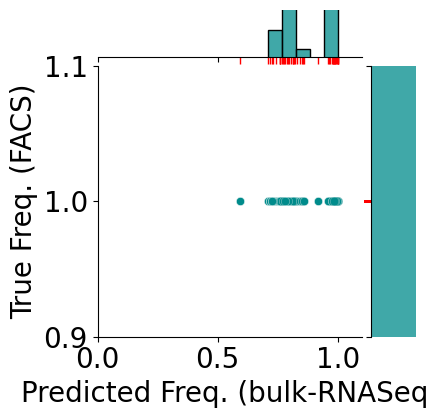

In [27]:
# fig, g = plt.subplots(figsize=(5,5))
g = sns.jointplot(data=df, x="stem", y="facs", xlim=(0, 1), color = 'darkcyan', height=4)
g.plot_joint(sns.kdeplot, color="r", zorder=0, levels=6)
g.plot_marginals(sns.rugplot, color="r", height=-.15, clip_on=False)

ax = plt.gca()
ax.tick_params(axis='y', labelsize=20)
ax.tick_params(axis='x', labelsize=20)
ax.set_ylabel(r'True Freq. (FACS)', fontsize=20)
ax.set_xlabel(r'Predicted Freq. (bulk-RNASeq)', fontsize=20)
ax.set_ylim(0.9, 1.1)
ax.set_xlim(0, 1.1)
# ax.spines['top'].set_visible(True)
# ax.spines['right'].set_visible(True)
# ax.set_title(r'GSE80213 BRCA Dataset (n=24)', fontsize=25)
g.ax_joint.scatter(df["stem"], df["facs"], s=30, alpha=0.1, color='darkcyan')
# plt.savefig('GSE80213 BRCA Dataset (n=24).svg', dpi=600, bbox_inches='tight')

Fig - 1.E

In [28]:
df = pd.read_csv('Data/Figure_Data/aml_nature.csv', index_col=(0))
df

,stem,LAML,Actual
AML556-D0,0.006126,0.993874,0.0120
AML707B-D0,0.322645,0.677355,0.4300
AML916-D0,0.134401,0.865599,0.0900
AML921A-D0,0.075398,0.924602,0.0843


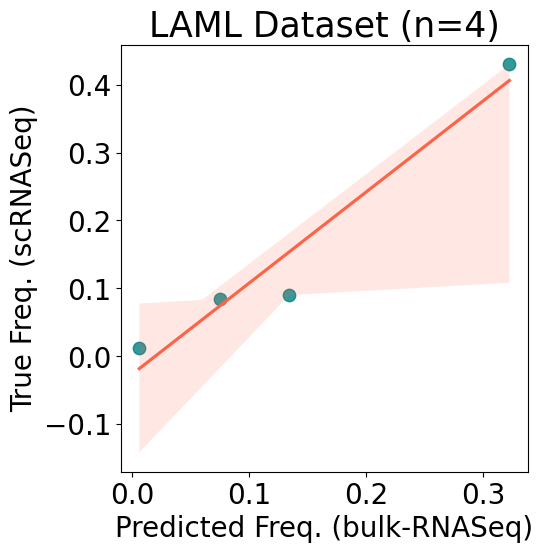

In [29]:
sns.lmplot(data=df, x="stem", y="Actual", scatter=True,
          scatter_kws={'color': 'teal', 's': 80, 'alpha': 0.8}, line_kws={'color': 'tomato'})

ax = plt.gca()
ax.tick_params(axis='y', labelsize=20)
ax.tick_params(axis='x', labelsize=20)
ax.set_ylabel(r'True Freq. (scRNASeq)', fontsize=20)
ax.set_xlabel(r'Predicted Freq. (bulk-RNASeq)', fontsize=20)
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)
ax.set_title(r'LAML Dataset (n=4)', fontsize=25)

# plt.savefig('rnaseq_regression.svg', dpi=600, bbox_inches='tight')
plt.show()

Fig - 1.F

In [30]:
df = pd.read_csv('Data/Figure_Data/tumor_stem_freq.csv', index_col=(0))
df['type'] = 'Malignant Fraction'
df

,stem,tumor,type
GSM1119322_MGG23_rep1.CEL.gz,0.148487,0.851513,Malignant Fraction
GSM1119323_MGG23_rep2.CEL.gz,0.160047,0.839953,Malignant Fraction
GSM1119324_MGG4_rep1.CEL.gz,0.168459,0.831541,Malignant Fraction
GSM1119325_MGG4_rep2.CEL.gz,0.237008,0.762992,Malignant Fraction
GSM1119326_MGG6_rep1.CEL.gz,0.093634,0.906366,Malignant Fraction
GSM1119327_MGG6_rep2.CEL.gz,0.087900,0.912100,Malignant Fraction
GSM1119328_MGG8_rep1.CEL.gz,0.294098,0.705902,Malignant Fraction
GSM1119329_MGG8_rep2.CEL.gz,0.312198,0.687802,Malignant Fraction
GSM1119330_MGG8_rep3.CEL.gz,0.231859,0.768141,Malignant Fraction
GSM1119331_MGG8_rep4.CEL.gz,0.226591,0.773409,Malignant Fraction


In [31]:
df2 = pd.read_csv('Data/Figure_Data/Stem_cell_validation.csv', index_col=(0))
df2['type'] = 'CSC Fraction'
df2 = df2[['stem', 'tumor', 'type']]
df2

,stem,tumor,type
GSM871443.CEL.gz,1.000000,0.000000,CSC Fraction
GSM871444.CEL.gz,0.999267,0.000733,CSC Fraction
GSM871445.CEL.gz,1.000000,0.000000,CSC Fraction
GSM871450.CEL.gz,0.798894,0.201106,CSC Fraction
GSM871483.CEL.gz,0.918496,0.081504,CSC Fraction
GSM871489.CEL.gz,0.594310,0.405690,CSC Fraction
GSM871512.CEL.gz,0.813401,0.186599,CSC Fraction
GSM871513.CEL.gz,0.818034,0.181966,CSC Fraction
GSM2121006_Wicha_001_2-S-D-AP.CEL.gz,0.992142,0.007858,CSC Fraction
GSM2121007_Wicha_002_3-S-D-AP.CEL.gz,0.979488,0.020512,CSC Fraction


In [32]:
df3 = pd.melt(df, id_vars=['type'], value_vars=['stem', 'tumor'])
df4 = pd.melt(df2, id_vars=['type'], value_vars=['stem', 'tumor'])
df5 = pd.concat([df3, df4], axis=0)
df5

,type,variable,value
0,Malignant Fraction,stem,0.148487
1,Malignant Fraction,stem,0.160047
2,Malignant Fraction,stem,0.168459
3,Malignant Fraction,stem,0.237008
4,Malignant Fraction,stem,0.093634
...,...,...,...
79,CSC Fraction,tumor,0.218852
80,CSC Fraction,tumor,0.145862
81,CSC Fraction,tumor,0.155280
82,CSC Fraction,tumor,0.148179


/opt/homebrew/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/homebrew/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/homebrew/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/homebrew/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_cat

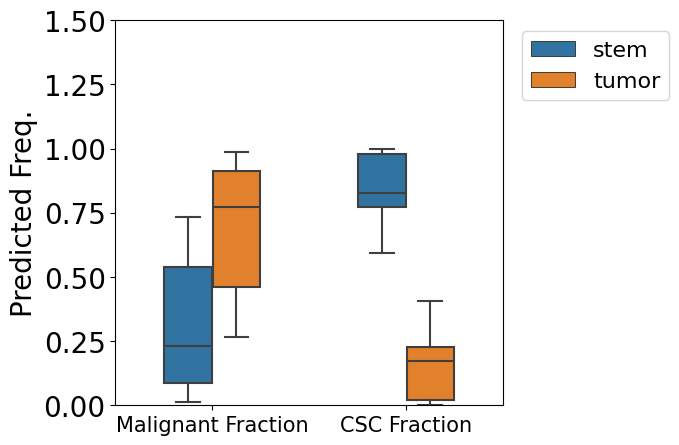

In [33]:
plt.figure(figsize=(5, 5))
sns.boxplot(data=df5, x="type", y="value", hue="variable", width=0.5)
ax = plt.gca()
ax.tick_params(axis='y', labelsize=20)
ax.tick_params(axis='x', labelsize=15)
ax.set_ylabel(r'Predicted Freq.', fontsize=20)
ax.set_xlabel('', fontsize=20)
ax.legend(fontsize=16, bbox_to_anchor=(1.02, 1), loc='upper left')

ax.set_ylim(0, 1.5)
# ax.set_xlim(0, 1.1)
# ax.spines['top'].set_visible(True)
# ax.spines['right'].set_visible(True)
# ax.set_title(r'Fraction-specific Prediction (tumor n=54, CSC n=42)', fontsize=18)

# g.ax_joint.scatter(df2["stem"], df2["facs"], s=30, alpha=0.1, color='darkcyan')
# plt.savefig('Fraction-specific prediction.svg', dpi=600, bbox_inches='tight')
plt.show()

Fig - 2.A (Sunburst) 

In [34]:
df = pd.read_csv('Data/Figure_Data/merged_class_types .csv')
df.label = [col.replace('hOPSC','hUSC') for col in df.label]

def type(x):
    if x == 'hUSC':
        return 'Progenitor cell'
    else:
        return 'Stem cell'
    
df['parent'] = df['label'].apply(lambda x: type(x))
df['values'] = list(df.index)
df

,cell_type,label,parent,values
0,adipose stem cell,hMSC,Stem cell,0
1,amniotic fluid cell,hUSC,Progenitor cell,1
2,angioblastic mesenchymal cell,hMSC,Stem cell,2
3,anterior foregut cell,hUSC,Progenitor cell,3
4,cardiac progenitor cell,hMSC,Stem cell,4
...,...,...,...,...
86,stromal cell,hUSC,Progenitor cell,86
87,tendon cell,hUSC,Progenitor cell,87
88,trophoblast cell,hUSC,Progenitor cell,88
89,trophoblast progenitor cell,hMSC,Stem cell,89


In [37]:


fig = px.sunburst(df, path=['parent', 'label', 'cell_type'], color='values', color_continuous_scale='BuPu')

# pio.renderers.default = 'kaleido'
pio.show(fig)

# pio.write_image(fig, 'sunburst.png', width=800, height=800, scale=3)

Fig - 2.B (No. of samples/class stemformatics)

In [38]:
df = {'Stem Cell Types': ['hMSC', 'iPSC', 'hUSC', 'hESC'],
        'No. of samples': [997, 896, 816, 585]}

df = pd.DataFrame(df)
df

,Stem Cell Types,No. of samples
0,hMSC,997
1,iPSC,896
2,hUSC,816
3,hESC,585


/opt/homebrew/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning:

is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead

/opt/homebrew/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning:

is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead

/opt/homebrew/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning:

is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead



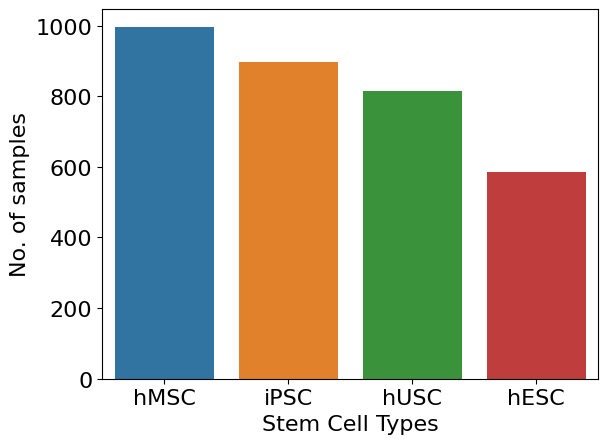

In [39]:
sns.barplot(data=df, x="Stem Cell Types", y="No. of samples")
ax = plt.gca()
ax.tick_params(axis='y', labelsize=16)
ax.tick_params(axis='x', labelsize=16)
ax.set_ylabel('No. of samples', fontsize=16)
ax.set_xlabel('Stem Cell Types', fontsize=16)
# plt.savefig('box_stmfr_samples.png', dpi=600, bbox_inches='tight')
plt.show()

Fig - 2.C ()

Fig - 2.D()

Fig - 2.E()

Fig - 2.F(DEseq stemformatics only marker genes)

In [40]:
mark = pd.read_csv('Data/Figure_Data/stem_marker.csv')
mark = list(mark['Merged'].drop_duplicates())
len(mark)

487

In [41]:

mg = mygene.MyGeneInfo()
out = mg.querymany(mark, scopes='symbol', fields='ensembl.gene', species='human',
                   verbose = False, returnall=True, size=1)
ensembl_list = []
for i in out['out']:
    try:
        ensembl_list.append(i['ensembl']['gene'])
    except:
        ensembl_list.append('None')
        
len(ensembl_list)

487

In [42]:
def assign_sign(value):
    if value >= 0:
        return 'Positive'
    else:
        return 'Negative'

def log10(value):
    return -np.log10(value)

df = pd.read_csv('Data/Figure_Data/stmfr_iPSC vs rest.csv', index_col=(0))  # change to hESC, hMSC, hUSC
df = df[df.index.isin(ensembl_list)]
df['sign'] = df['log2FoldChange'].apply(assign_sign)
df['norm'] = (df['baseMean']-min(df['baseMean']))/(max(df['baseMean'])-min(df['baseMean']))
df['p_log'] = df['pvalue'].apply(log10)
df

/var/folders/rf/3w2r5qss4cg6yvzsxmr48cl00000gn/T/ipykernel_27558/2919507019.py:8: RuntimeWarning:

divide by zero encountered in log10



,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,sign,norm,p_log
ENSG00000003249,2212.87770,0.121513,0.060095,2.022015,4.317484e-02,4.871758e-02,Positive,0.024930,1.364769
ENSG00000004468,348.19934,0.991684,0.081543,12.161436,4.987437e-34,1.310296e-33,Positive,0.003385,33.302123
ENSG00000006468,1155.00940,0.769254,0.076636,10.037746,1.040243e-23,2.164689e-23,Positive,0.012707,22.982865
ENSG00000006652,2266.53220,-0.190325,0.033540,-5.674592,1.390197e-08,2.013608e-08,Negative,0.025550,7.856924
ENSG00000007392,2575.13100,0.628460,0.036715,17.117371,1.101375e-65,5.597993e-65,Positive,0.029116,64.958065
...,...,...,...,...,...,...,...,...,...
ENSG00000239900,6085.62740,-0.313218,0.044950,-6.968213,3.209927e-12,5.147226e-12,Negative,0.069676,11.493505
ENSG00000240563,8137.53170,1.995588,0.103446,19.291062,6.384856e-83,4.783650e-82,Positive,0.093385,82.194849
ENSG00000241945,860.74304,1.395467,0.057459,24.286155,2.745649e-130,6.591758e-129,Positive,0.009307,129.561355
ENSG00000253729,3273.93730,0.083629,0.032974,2.536195,1.120644e-02,1.307237e-02,Positive,0.037190,1.950532


/opt/homebrew/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning:

is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead

/opt/homebrew/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning:

is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead

/opt/homebrew/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

/opt/homebrew/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.



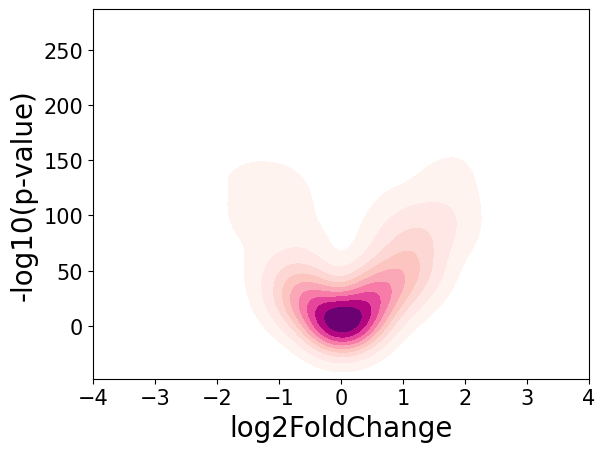

In [43]:

sns.kdeplot(x=df.log2FoldChange, y=df.p_log, cmap="RdPu", fill=True, bw_adjust=1)

# plt.ylim(0, 200)
plt.xlim(-4, 4)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

plt.ylabel("-log10(p-value)", fontsize=20)
plt.xlabel("log2FoldChange", fontsize=20)

# plt.savefig("stmfr_density_hmsc.png", dpi=600, bbox_inches='tight')
plt.show()

Fig - 3 (From classifier model)

Fig - 4.A,B,C ()

In [44]:
df = pd.read_csv('Data/Figure_Data/22_analysis.csv', index_col=(0))
df

,Cancer,predicted_label,ITH,MCE,Scent,T cells CD8,Monocytes,T cells CD4,NKT cells,B cells,...,KIRC,OV,LAML,GBM,CESC,CHOL,LIHC,BRCA,LGG,HNSC
TCGA-05-4244-01,LUAD,hESC,1.550568,0.865286,0.963758,0.000000,0.039980,0.000000,0.073005,0.000000,...,0.000000,0.066900,0.000000,0.000000,0.020913,0.017971,0.001756,0.026924,0.000000,0.062705
TCGA-05-4249-01,LUAD,hMSC,1.522665,0.863655,0.962889,0.006788,0.044550,0.000000,0.000000,0.000000,...,0.000000,0.077520,0.000000,0.000000,0.023272,0.000000,0.027158,0.038166,0.000000,0.083833
TCGA-05-4250-01,LUAD,hMSC,1.481596,0.867993,0.965142,0.005432,0.046202,0.000000,0.016369,0.000000,...,0.037647,0.073750,0.001643,0.008069,0.000000,0.004955,0.000000,0.004632,0.000000,0.055172
TCGA-05-4382-01,LUAD,hESC,1.861928,0.863094,0.962964,0.000000,0.073508,0.000000,0.003176,0.000000,...,0.002395,0.059701,0.000061,0.002624,0.054136,0.000000,0.012245,0.019079,0.000000,0.060875
TCGA-05-4384-01,LUAD,hMSC,1.335044,0.862890,0.962012,0.000000,0.052751,0.000000,0.000000,0.000000,...,0.000000,0.110010,0.000934,0.000000,0.021982,0.013282,0.074750,0.077159,0.000000,0.021030
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-61-2113-01,OV,iPSC,1.469182,0.864652,0.963663,0.000000,0.021256,0.000000,0.000953,0.000000,...,0.000000,0.258790,0.000000,0.000000,0.051753,0.000000,0.000778,0.000000,0.000000,0.099472
TCGA-OY-A56P-01,OV,iPSC,2.031723,0.865035,0.963706,0.000000,0.000000,0.051863,0.014616,0.000000,...,0.000000,0.225032,0.000000,0.004164,0.015711,0.000000,0.005041,0.000272,0.092499,0.072270
TCGA-OY-A56Q-01,OV,iPSC,2.026093,0.864030,0.963554,0.000000,0.000000,0.017332,0.000000,0.000000,...,0.000000,0.332592,0.003186,0.000000,0.000000,0.015688,0.003149,0.052760,0.138610,0.075669
TCGA-VG-A8LO-01,OV,iPSC,1.785248,0.865939,0.964522,0.000000,0.000000,0.006477,0.001433,0.002782,...,0.000000,0.460801,0.000000,0.000000,0.045749,0.000000,0.016104,0.018896,0.000000,0.087816


In [45]:
patient_cut = [i[:-3] for i in df.index]

In [46]:
df = df.set_axis(patient_cut)
df = df[['predicted_label', 'stem', 'Cancer']]
df = df[~df.index.duplicated(keep='first')]
df

,predicted_label,stem,Cancer
TCGA-05-4244,hESC,0.018238,LUAD
TCGA-05-4249,hMSC,0.042426,LUAD
TCGA-05-4250,hMSC,0.071180,LUAD
TCGA-05-4382,hESC,0.037569,LUAD
TCGA-05-4384,hMSC,0.010948,LUAD
...,...,...,...
TCGA-61-2113,iPSC,0.124652,OV
TCGA-OY-A56P,iPSC,0.180374,OV
TCGA-OY-A56Q,iPSC,0.178266,OV
TCGA-VG-A8LO,iPSC,0.143781,OV


In [47]:
patient_info = pd.read_csv('Data/Figure_Data/patient_info.csv')
patient_info = patient_info[patient_info['PATIENT_ID'].isin(patient_cut)]
patient_info = patient_info.set_index('PATIENT_ID')
patient_info

,SUBTYPE,CANCER_TYPE_ACRONYM,OTHER_PATIENT_ID,AGE,SEX,AJCC_PATHOLOGIC_TUMOR_STAGE,AJCC_STAGING_EDITION,DAYS_LAST_FOLLOWUP,DAYS_TO_BIRTH,DAYS_TO_INITIAL_PATHOLOGIC_DIAGNOSIS,...,WEIGHT,IN_PANCANPATHWAYS_FREEZE,OS_STATUS,OS_MONTHS,DSS_STATUS,DSS_MONTHS,DFS_STATUS,DFS_MONTHS,PFS_STATUS,PFS_MONTHS
PATIENT_ID,,,,,,,,,,,,,,,,,,,,,
TCGA-AB-3008,LAML,LAML,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,Yes,1:DECEASED,27.024361,NaN,NaN,NaN,NaN,NaN,NaN
TCGA-AB-2863,LAML,LAML,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,Yes,1:DECEASED,1.019167,NaN,NaN,NaN,NaN,NaN,NaN
TCGA-AB-2844,LAML,LAML,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,Yes,1:DECEASED,4.010915,NaN,NaN,NaN,NaN,NaN,NaN
TCGA-AB-2955,LAML,LAML,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,Yes,1:DECEASED,16.076536,NaN,NaN,NaN,NaN,NaN,NaN
TCGA-AB-2897,LAML,LAML,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,Yes,0:LIVING,7.988954,0:ALIVE OR DEAD TUMOR FREE,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-VQ-AA6I,STAD_CIN,STAD,3CCBE7C7-C779-4A98-B495-FF020D3E9E55,68.0,Male,STAGE IIIB,7TH,NaN,-25091.0,0.0,...,NaN,Yes,1:DECEASED,16.142289,1:DEAD WITH TUMOR,16.142289,NaN,NaN,1:PROGRESSION,15.616267
TCGA-VQ-AA6J,STAD_CIN,STAD,A267DDB4-B2D9-4292-B120-6E13E70D01F8,75.0,Male,STAGE IIIB,7TH,838.0,-27506.0,0.0,...,NaN,Yes,0:LIVING,27.550383,0:ALIVE OR DEAD TUMOR FREE,27.550383,0:DiseaseFree,27.550383,0:CENSORED,27.550383
TCGA-VQ-AA6K,STAD_CIN,STAD,83A0F9EF-4BF0-4EFE-8713-F8B6AB4F5773,59.0,Male,STAGE IIIC,6TH,NaN,-21901.0,0.0,...,NaN,Yes,1:DECEASED,12.427261,1:DEAD WITH TUMOR,12.427261,NaN,NaN,1:PROGRESSION,10.914949


In [48]:
req = patient_info[['SEX']].dropna()
req = req[~req.index.duplicated(keep='first')]
req

,SEX
PATIENT_ID,
TCGA-CS-4938,Female
TCGA-CS-4941,Male
TCGA-CS-4942,Female
TCGA-CS-4943,Male
TCGA-CS-4944,Male
...,...
TCGA-VQ-AA6I,Male
TCGA-VQ-AA6J,Male
TCGA-VQ-AA6K,Male


In [49]:
req1 = patient_info[['AGE']].dropna()
req1 = req1[~req1.index.duplicated(keep='first')]
req1

,AGE
PATIENT_ID,
TCGA-CS-4938,31.0
TCGA-CS-4941,67.0
TCGA-CS-4942,44.0
TCGA-CS-4943,37.0
TCGA-CS-4944,50.0
...,...
TCGA-VQ-AA6I,68.0
TCGA-VQ-AA6J,75.0
TCGA-VQ-AA6K,59.0


In [50]:
data = pd.concat([df, req], axis=1).dropna()
data

,predicted_label,stem,Cancer,SEX
TCGA-05-4244,hESC,0.018238,LUAD,Male
TCGA-05-4249,hMSC,0.042426,LUAD,Male
TCGA-05-4250,hMSC,0.071180,LUAD,Female
TCGA-05-4382,hESC,0.037569,LUAD,Male
TCGA-05-4384,hMSC,0.010948,LUAD,Male
...,...,...,...,...
TCGA-61-2113,iPSC,0.124652,OV,Female
TCGA-OY-A56P,iPSC,0.180374,OV,Female
TCGA-OY-A56Q,iPSC,0.178266,OV,Female
TCGA-VG-A8LO,iPSC,0.143781,OV,Female


In [51]:
data1 = pd.concat([df, req1], axis=1).dropna()
data1

,predicted_label,stem,Cancer,AGE
TCGA-05-4244,hESC,0.018238,LUAD,70.0
TCGA-05-4249,hMSC,0.042426,LUAD,67.0
TCGA-05-4250,hMSC,0.071180,LUAD,79.0
TCGA-05-4382,hESC,0.037569,LUAD,68.0
TCGA-05-4384,hMSC,0.010948,LUAD,66.0
...,...,...,...,...
TCGA-61-2113,iPSC,0.124652,OV,53.0
TCGA-OY-A56P,iPSC,0.180374,OV,48.0
TCGA-OY-A56Q,iPSC,0.178266,OV,78.0
TCGA-VG-A8LO,iPSC,0.143781,OV,55.0


In [52]:
grouped_sex = data.groupby('predicted_label')
label_list = ['iPSC', 'hESC', 'hMSC', 'hUSC']

In [53]:
sex_list = []
for i in label_list:
    sex_df = grouped_sex.get_group(i)
    sex_list.append(sex_df['SEX'].value_counts()['Male'])
    sex_list.append(sex_df['SEX'].value_counts()['Female'])
    
sex_list

[1092, 1092, 851, 879, 777, 1025, 992, 895]

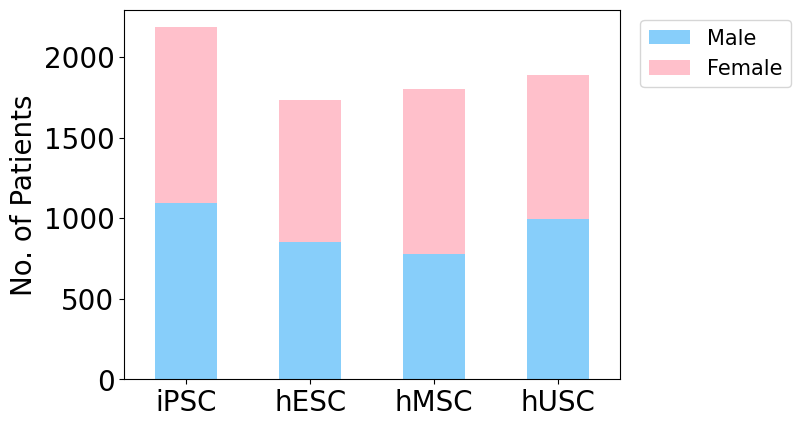

In [54]:
df = pd.DataFrame({'Male': [1092, 851, 777, 992],
                   'Female': [1092, 879, 1025, 895]},
                  index=['iPSC', 'hESC', 'hMSC', 'hUSC'])
                   
df.plot(kind='bar', stacked=True, color=['lightskyblue', 'pink'])
ax = plt.gca()
ax.tick_params(axis='y', labelsize=20)
ax.tick_params(axis='x', labelsize=20, rotation=0)

ax.set_xlabel('', fontsize=20)  
ax.set_ylabel('No. of Patients', fontsize=20)
ax.legend(fontsize=15, bbox_to_anchor=(1.02, 1), loc='upper left')

# plt.savefig('bar_sex.png', dpi=600, bbox_inches='tight')
plt.show()

/opt/homebrew/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning:

is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead

/opt/homebrew/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning:

is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead

/opt/homebrew/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning:

is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead

/opt/homebrew/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning:

is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead



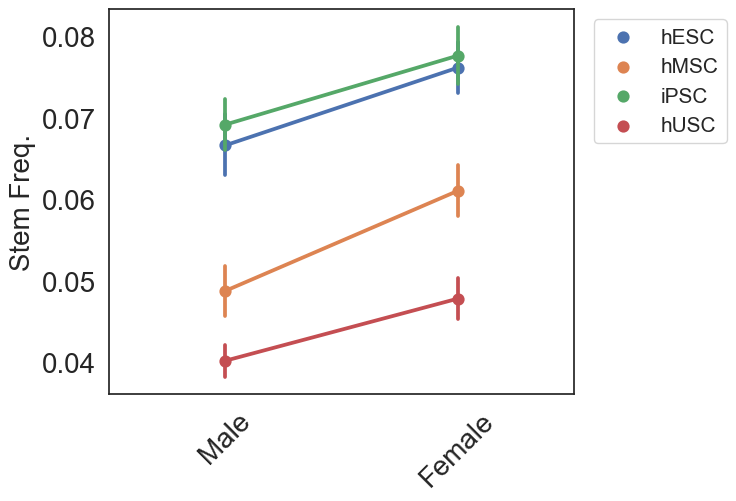

In [55]:
sns.set(rc={'figure.figsize':(6,5)})

sns.set_style('white')

sns.pointplot(data=data, x="SEX", y="stem", hue='predicted_label')
ax = plt.gca()
ax.tick_params(axis='y', labelsize=20)
ax.tick_params(axis='x', labelsize=20, rotation=45)

ax.set_xlabel('', fontsize=20)  
ax.set_ylabel('Stem Freq.', fontsize=20)
ax.legend(fontsize=15, bbox_to_anchor=(1.02, 1), loc='upper left')

# plt.savefig('point_stem_lymph.png', dpi=600, bbox_inches='tight')

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


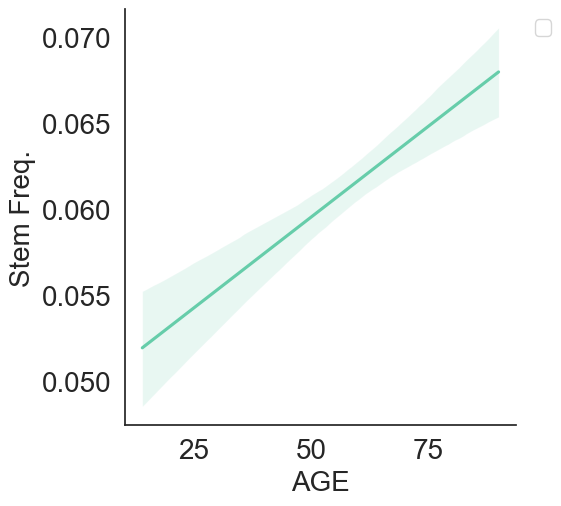

In [56]:
sns.lmplot(x ='AGE', y ='stem', data = data1, scatter=False,
          scatter_kws={'color': 'gray', 's': 10, 'alpha': 0.2}, line_kws={'color': 'mediumaquamarine'},
           ci=95)

ax = plt.gca()
# plt.ylim(0, 0.1)
# plt.xlim(0.7, 1.0)
ax.tick_params(axis='y', labelsize=20)
ax.tick_params(axis='x', labelsize=20)
ax.set_xlabel('AGE', fontsize=20)
ax.set_ylabel('Stem Freq.', fontsize=20)
ax.legend(fontsize=15, bbox_to_anchor=(1.02, 1), loc='upper left')

# plt.savefig('reg_stem_age.png', dpi=600, bbox_inches='tight')

Fig - 4.D,E,F

In [57]:
df = pd.read_csv('Data/Figure_Data/22_analysis.csv', index_col=(0))
df = df[['predicted_label', 'stem', 'Cancer']]
df

,predicted_label,stem,Cancer
TCGA-05-4244-01,hESC,0.018238,LUAD
TCGA-05-4249-01,hMSC,0.042426,LUAD
TCGA-05-4250-01,hMSC,0.071180,LUAD
TCGA-05-4382-01,hESC,0.037569,LUAD
TCGA-05-4384-01,hMSC,0.010948,LUAD
...,...,...,...
TCGA-61-2113-01,iPSC,0.124652,OV
TCGA-OY-A56P-01,iPSC,0.180374,OV
TCGA-OY-A56Q-01,iPSC,0.178266,OV
TCGA-VG-A8LO-01,iPSC,0.143781,OV


In [61]:
patient_detail = pd.read_csv('Data/Figure_Data/patient_detail.csv')
patient_detail = patient_detail.set_index('SAMPLE_ID')
patient_detail

,PATIENT_ID,ONCOTREE_CODE,CANCER_TYPE,CANCER_TYPE_DETAILED,TUMOR_TYPE,GRADE,TISSUE_PROSPECTIVE_COLLECTION_INDICATOR,TISSUE_RETROSPECTIVE_COLLECTION_INDICATOR,TISSUE_SOURCE_SITE_CODE,TUMOR_TISSUE_SITE,ANEUPLOIDY_SCORE,SAMPLE_TYPE,MSI_SCORE_MANTIS,MSI_SENSOR_SCORE,SOMATIC_STATUS,TMB_NONSYNONYMOUS,TISSUE_SOURCE_SITE
SAMPLE_ID,,,,,,,,,,,,,,,,,
TCGA-2K-A9WE-01,TCGA-2K-A9WE,PRCC,Renal Non-Clear Cell Carcinoma,Papillary Renal Cell Carcinoma,Kidney Papillary Renal Cell Carcinoma,NaN,No,Yes,2K,Kidney,12.0,Primary,0.3053,0.00,Matched,1.833333,Greenville Health System
TCGA-2Z-A9J1-01,TCGA-2Z-A9J1,PRCC,Renal Non-Clear Cell Carcinoma,Papillary Renal Cell Carcinoma,Kidney Papillary Renal Cell Carcinoma,NaN,No,Yes,2Z,Kidney,13.0,Primary,0.3150,0.18,Matched,2.833333,Moffitt Cancer Center
TCGA-2Z-A9J2-01,TCGA-2Z-A9J2,PRCC,Renal Non-Clear Cell Carcinoma,Papillary Renal Cell Carcinoma,Kidney Papillary Renal Cell Carcinoma,NaN,No,Yes,2Z,Kidney,7.0,Primary,0.3179,0.10,Matched,2.366667,Moffitt Cancer Center
TCGA-2Z-A9J3-01,TCGA-2Z-A9J3,PRCC,Renal Non-Clear Cell Carcinoma,Papillary Renal Cell Carcinoma,Kidney Papillary Renal Cell Carcinoma,NaN,No,Yes,2Z,Kidney,10.0,Primary,0.3320,0.18,Matched,4.166667,Moffitt Cancer Center
TCGA-2Z-A9J5-01,TCGA-2Z-A9J5,PRCC,Renal Non-Clear Cell Carcinoma,Papillary Renal Cell Carcinoma,Kidney Papillary Renal Cell Carcinoma,NaN,No,Yes,2Z,Kidney,12.0,Primary,0.3098,0.01,Matched,2.933333,Moffitt Cancer Center
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-VQ-AA6I-01,TCGA-VQ-AA6I,ISTAD,Esophagogastric Cancer,Intestinal Type Stomach Adenocarcinoma,Stomach Intestinal Adenocarcinoma (NOS),G3,No,Yes,VQ,Stomach,15.0,Primary,0.3350,0.09,Matched,2.933333,Barretos Cancer Hospital
TCGA-VQ-AA6J-01,TCGA-VQ-AA6J,ISTAD,Esophagogastric Cancer,Intestinal Type Stomach Adenocarcinoma,Stomach Intestinal Adenocarcinoma (NOS),G3,No,Yes,VQ,Stomach,9.0,Primary,0.3303,0.00,Matched,4.200000,Barretos Cancer Hospital
TCGA-VQ-AA6K-01,TCGA-VQ-AA6K,SSRCC,Esophagogastric Cancer,Signet Ring Cell Carcinoma of the Stomach,"Stomach Adenocarcinoma, Signet Ring Type",G3,No,Yes,VQ,Stomach,14.0,Primary,0.3231,0.08,Matched,2.500000,Barretos Cancer Hospital


In [60]:
req = patient_detail[['MSI_SCORE_MANTIS']].dropna()
req = req[~req.index.duplicated(keep='first')]
req

,MSI_SCORE_MANTIS
SAMPLE_ID,
TCGA-2K-A9WE-01,0.3053
TCGA-2Z-A9J1-01,0.3150
TCGA-2Z-A9J2-01,0.3179
TCGA-2Z-A9J3-01,0.3320
TCGA-2Z-A9J5-01,0.3098
...,...
TCGA-VQ-AA6I-01,0.3350
TCGA-VQ-AA6J-01,0.3303
TCGA-VQ-AA6K-01,0.3231


In [62]:
req1 = patient_detail[['ANEUPLOIDY_SCORE']].dropna()
req1 = req1[~req1.index.duplicated(keep='first')]
req1

,ANEUPLOIDY_SCORE
SAMPLE_ID,
TCGA-2K-A9WE-01,12.0
TCGA-2Z-A9J1-01,13.0
TCGA-2Z-A9J2-01,7.0
TCGA-2Z-A9J3-01,10.0
TCGA-2Z-A9J5-01,12.0
...,...
TCGA-VQ-AA6I-01,15.0
TCGA-VQ-AA6J-01,9.0
TCGA-VQ-AA6K-01,14.0


In [63]:
data = pd.concat([df, req], axis=1).dropna()
data

,predicted_label,stem,Cancer,MSI_SCORE_MANTIS
TCGA-05-4244-01,hESC,0.018238,LUAD,0.2886
TCGA-05-4249-01,hMSC,0.042426,LUAD,0.2807
TCGA-05-4250-01,hMSC,0.071180,LUAD,0.3059
TCGA-05-4382-01,hESC,0.037569,LUAD,0.3193
TCGA-05-4384-01,hMSC,0.010948,LUAD,0.2850
...,...,...,...,...
TCGA-61-2113-01,iPSC,0.124652,OV,0.3072
TCGA-OY-A56P-01,iPSC,0.180374,OV,0.3369
TCGA-OY-A56Q-01,iPSC,0.178266,OV,0.3403
TCGA-VG-A8LO-01,iPSC,0.143781,OV,0.3383


In [64]:
data1 = pd.concat([df, req1], axis=1).dropna()
data1

,predicted_label,stem,Cancer,ANEUPLOIDY_SCORE
TCGA-05-4244-01,hESC,0.018238,LUAD,17.0
TCGA-05-4249-01,hMSC,0.042426,LUAD,24.0
TCGA-05-4250-01,hMSC,0.071180,LUAD,17.0
TCGA-05-4382-01,hESC,0.037569,LUAD,22.0
TCGA-05-4384-01,hMSC,0.010948,LUAD,1.0
...,...,...,...,...
TCGA-61-2113-01,iPSC,0.124652,OV,28.0
TCGA-OY-A56P-01,iPSC,0.180374,OV,27.0
TCGA-OY-A56Q-01,iPSC,0.178266,OV,28.0
TCGA-VG-A8LO-01,iPSC,0.143781,OV,8.0


/opt/homebrew/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning:

is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead

/opt/homebrew/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning:

is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead



Text(0.5, 33.203125, 'MSI MANTIS SCORE')

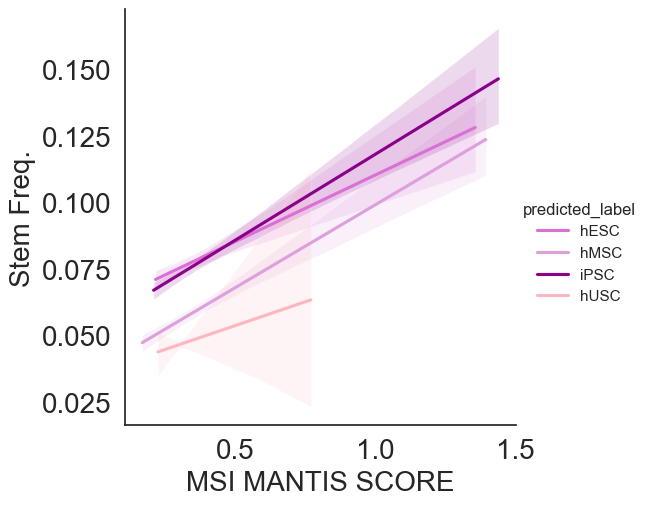

In [65]:
custom_palette = {
    'iPSC': 'darkmagenta',
    'hESC': 'orchid',
    'hMSC': 'plum',
    'hUSC': 'lightpink'
}

sns.set_style('white')

sns.lmplot(x ='MSI_SCORE_MANTIS', y ='stem', data = data,
           hue ='predicted_label', scatter=False,
          palette=custom_palette)
ax = plt.gca()

ax.tick_params(axis='y', labelsize=20)
ax.tick_params(axis='x', labelsize=20)
ax.set_ylabel('Stem Freq.', fontsize=20)
ax.set_xlabel('MSI MANTIS SCORE', fontsize=20)

/opt/homebrew/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning:

is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead

/opt/homebrew/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning:

is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead



Text(0.5, 33.203125, 'ANEUPLOIDY SCORE')

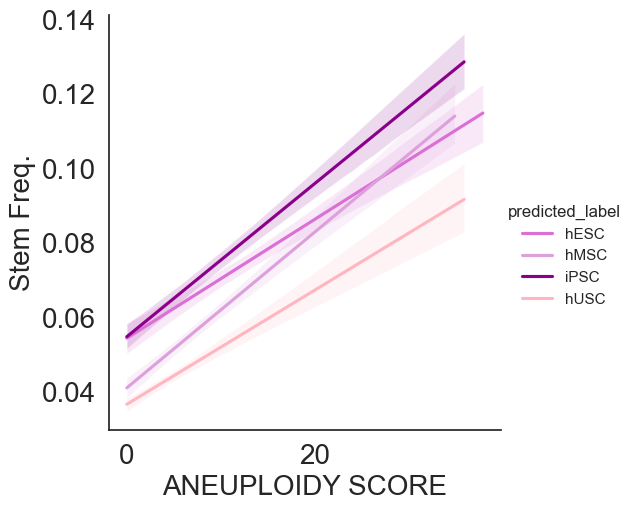

In [66]:
custom_palette = {
    'iPSC': 'darkmagenta',
    'hESC': 'orchid',
    'hMSC': 'plum',
    'hUSC': 'lightpink'
}

sns.set_style('white')

sns.lmplot(x ='ANEUPLOIDY_SCORE', y ='stem', data = data1,
           hue ='predicted_label', scatter=False,
          palette=custom_palette)
ax = plt.gca()

ax.tick_params(axis='y', labelsize=20)
ax.tick_params(axis='x', labelsize=20)
ax.set_ylabel('Stem Freq.', fontsize=20)
ax.set_xlabel('ANEUPLOIDY SCORE', fontsize=20)

/opt/homebrew/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning:

is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead

/opt/homebrew/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning:

is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead

/opt/homebrew/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning:

is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead

/opt/homebrew/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning:

is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead

/opt/homebrew/lib/python3.11/site-packages/seaborn/categorical.py:1680: UserWarning:

You passed a edgecolor/edgecolors ([(0.1, 0.1, 0.1), (0.1, 0.1, 0.1), (0.1

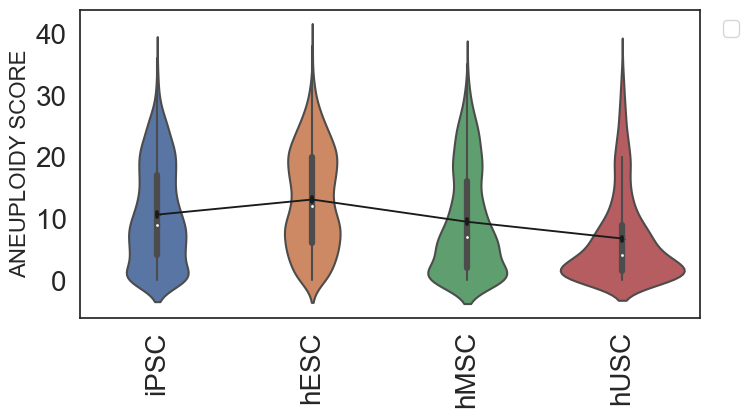

In [67]:
sns.set(rc={'figure.figsize':(8,4)})

sns.set_style('white')

sns.violinplot(data=data1, x="predicted_label", y="ANEUPLOIDY_SCORE", order=['iPSC', 'hESC', 'hMSC', 'hUSC'])
sns.pointplot(data=data1, x="predicted_label", y="ANEUPLOIDY_SCORE", order=['iPSC', 'hESC', 'hMSC', 'hUSC'], color='k', markers='_', scale=0.5)

ax = plt.gca()
ax.tick_params(axis='y', labelsize=20)
ax.tick_params(axis='x', labelsize=20, rotation=90)

ax.set_xlabel('', fontsize=20)  
ax.set_ylabel('ANEUPLOIDY SCORE', fontsize=16)
ax.legend(fontsize=15, bbox_to_anchor=(1.02, 1), loc='upper left')

# plt.savefig('violin_aneuploidy.png', dpi=600, bbox_inches='tight')

Fig - 5.B

Fig - 5.C

Fig - 5.D

Fig - 6.B

In [68]:
df = pd.read_csv('Data/Figure_Data/22_analysis.csv', index_col=(0))
df = df[['predicted_label', 'stem', 'Cancer']]
df['predicted_label'] = df['predicted_label'].replace({
    'hESC': 'ECSC',
    'hMSC': 'MCSC',
    'iPSC': 'iPCSC',
    'hUSC': 'UCSC'
})
df

,predicted_label,stem,Cancer
TCGA-05-4244-01,ECSC,0.018238,LUAD
TCGA-05-4249-01,MCSC,0.042426,LUAD
TCGA-05-4250-01,MCSC,0.071180,LUAD
TCGA-05-4382-01,ECSC,0.037569,LUAD
TCGA-05-4384-01,MCSC,0.010948,LUAD
...,...,...,...
TCGA-61-2113-01,iPCSC,0.124652,OV
TCGA-OY-A56P-01,iPCSC,0.180374,OV
TCGA-OY-A56Q-01,iPCSC,0.178266,OV
TCGA-VG-A8LO-01,iPCSC,0.143781,OV


In [69]:
patient_detail = pd.read_csv('Data/Figure_Data/patient_detail.csv')
patient_detail = patient_detail.set_index('SAMPLE_ID')
patient_detail

,PATIENT_ID,ONCOTREE_CODE,CANCER_TYPE,CANCER_TYPE_DETAILED,TUMOR_TYPE,GRADE,TISSUE_PROSPECTIVE_COLLECTION_INDICATOR,TISSUE_RETROSPECTIVE_COLLECTION_INDICATOR,TISSUE_SOURCE_SITE_CODE,TUMOR_TISSUE_SITE,ANEUPLOIDY_SCORE,SAMPLE_TYPE,MSI_SCORE_MANTIS,MSI_SENSOR_SCORE,SOMATIC_STATUS,TMB_NONSYNONYMOUS,TISSUE_SOURCE_SITE
SAMPLE_ID,,,,,,,,,,,,,,,,,
TCGA-2K-A9WE-01,TCGA-2K-A9WE,PRCC,Renal Non-Clear Cell Carcinoma,Papillary Renal Cell Carcinoma,Kidney Papillary Renal Cell Carcinoma,NaN,No,Yes,2K,Kidney,12.0,Primary,0.3053,0.00,Matched,1.833333,Greenville Health System
TCGA-2Z-A9J1-01,TCGA-2Z-A9J1,PRCC,Renal Non-Clear Cell Carcinoma,Papillary Renal Cell Carcinoma,Kidney Papillary Renal Cell Carcinoma,NaN,No,Yes,2Z,Kidney,13.0,Primary,0.3150,0.18,Matched,2.833333,Moffitt Cancer Center
TCGA-2Z-A9J2-01,TCGA-2Z-A9J2,PRCC,Renal Non-Clear Cell Carcinoma,Papillary Renal Cell Carcinoma,Kidney Papillary Renal Cell Carcinoma,NaN,No,Yes,2Z,Kidney,7.0,Primary,0.3179,0.10,Matched,2.366667,Moffitt Cancer Center
TCGA-2Z-A9J3-01,TCGA-2Z-A9J3,PRCC,Renal Non-Clear Cell Carcinoma,Papillary Renal Cell Carcinoma,Kidney Papillary Renal Cell Carcinoma,NaN,No,Yes,2Z,Kidney,10.0,Primary,0.3320,0.18,Matched,4.166667,Moffitt Cancer Center
TCGA-2Z-A9J5-01,TCGA-2Z-A9J5,PRCC,Renal Non-Clear Cell Carcinoma,Papillary Renal Cell Carcinoma,Kidney Papillary Renal Cell Carcinoma,NaN,No,Yes,2Z,Kidney,12.0,Primary,0.3098,0.01,Matched,2.933333,Moffitt Cancer Center
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-VQ-AA6I-01,TCGA-VQ-AA6I,ISTAD,Esophagogastric Cancer,Intestinal Type Stomach Adenocarcinoma,Stomach Intestinal Adenocarcinoma (NOS),G3,No,Yes,VQ,Stomach,15.0,Primary,0.3350,0.09,Matched,2.933333,Barretos Cancer Hospital
TCGA-VQ-AA6J-01,TCGA-VQ-AA6J,ISTAD,Esophagogastric Cancer,Intestinal Type Stomach Adenocarcinoma,Stomach Intestinal Adenocarcinoma (NOS),G3,No,Yes,VQ,Stomach,9.0,Primary,0.3303,0.00,Matched,4.200000,Barretos Cancer Hospital
TCGA-VQ-AA6K-01,TCGA-VQ-AA6K,SSRCC,Esophagogastric Cancer,Signet Ring Cell Carcinoma of the Stomach,"Stomach Adenocarcinoma, Signet Ring Type",G3,No,Yes,VQ,Stomach,14.0,Primary,0.3231,0.08,Matched,2.500000,Barretos Cancer Hospital


In [70]:
req = patient_detail[['GRADE']].dropna()
req = req[~req.index.duplicated(keep='first')]
req

,GRADE
SAMPLE_ID,
TCGA-CS-4938-01,G2
TCGA-CS-4941-01,G3
TCGA-CS-4942-01,G3
TCGA-CS-4943-01,G3
TCGA-CS-4944-01,G2
...,...
TCGA-VQ-AA6I-01,G3
TCGA-VQ-AA6J-01,G3
TCGA-VQ-AA6K-01,G3


In [71]:
data = pd.concat([df, req], axis=1).dropna()
data

,predicted_label,stem,Cancer,GRADE
TCGA-2W-A8YY-01,ECSC,0.147208,CESC,G3
TCGA-4J-AA1J-01,iPCSC,0.074090,CESC,G3
TCGA-BI-A0VR-01,ECSC,0.089825,CESC,G3
TCGA-BI-A0VS-01,iPCSC,0.105564,CESC,G3
TCGA-BI-A20A-01,ECSC,0.051815,CESC,G3
...,...,...,...,...
TCGA-61-2113-01,iPCSC,0.124652,OV,G3
TCGA-OY-A56P-01,iPCSC,0.180374,OV,G3
TCGA-OY-A56Q-01,iPCSC,0.178266,OV,G3
TCGA-VG-A8LO-01,iPCSC,0.143781,OV,GB


In [72]:
grade_list = ['G1', 'G2', 'G3', 'G4']
label_list = ['iPCSC', 'ECSC', 'MCSC', 'UCSC']
grouped_grade = data.groupby('GRADE')

In [73]:
ipsc_gr = []
hmsc_gr = []
hesc_gr = []
husc_gr = []
for i in grade_list:
    grade_df = grouped_grade.get_group(i)
    try:
        ipsc_gr.append(grade_df[grade_df['predicted_label'] == 'iPCSC']['stem'].mean())
    except:
        ipsc_gr.append(0)
    try:
        hmsc_gr.append(grade_df[grade_df['predicted_label'] == 'MCSC']['stem'].mean())
    except:
        hmsc_gr.append(0)
    try:
        hesc_gr.append(grade_df[grade_df['predicted_label'] == 'ECSC']['stem'].mean())
    except:
        hesc_gr.append(0)
    try:
        husc_gr.append(grade_df[grade_df['predicted_label'] == 'UCSC']['stem'].mean())
    except:
        husc_gr.append(0)

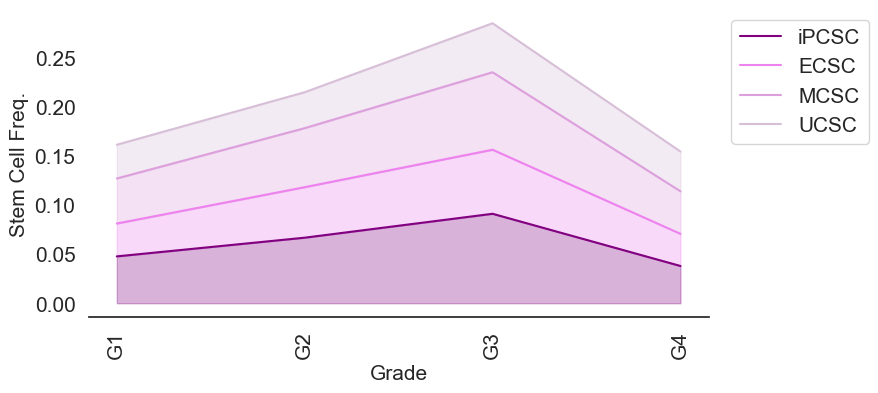

In [74]:
df = pd.DataFrame([ipsc_gr, hesc_gr, hmsc_gr, husc_gr], index=label_list, columns=grade_list).T

fig, ax = plt.subplots()
df.plot(kind='line', stacked=True, color=['purple', 'violet', 'plum', 'thistle'], alpha=1, ax=ax)

for i, cell_type in enumerate(df.columns):
    ax.fill_between(df.index, df.iloc[:, :i+1].sum(axis=1), df.iloc[:, :i].sum(axis=1) if i > 0 else 0, color=['purple', 'violet', 'plum', 'thistle'][i], alpha=0.3)

ax.set_xticks(range(len(df.index)))
ax.set_xticklabels(df.index, rotation=90, fontsize=15)
ax.tick_params(axis='y', labelsize=15)
legend = ax.legend(fontsize=15, bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_ylabel("Stem Cell Freq.", fontsize=15)
ax.set_xlabel("Grade", fontsize=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
# plt.savefig('grade_mean_stem.png', dpi = 600, bbox_inches='tight')
plt.show()

Fig - 6.A,C,D,E

In [75]:
df = pd.read_csv('Data/Figure_Data/22_analysis.csv', index_col=(0))
df = df[['predicted_label', 'stem', 'Cancer']]
df['predicted_label'] = df['predicted_label'].replace({
    'hESC': 'ECSC',
    'hMSC': 'MCSC',
    'iPSC': 'iPCSC',
    'hUSC': 'UCSC'
})
df.index = [i[:-3] for i in df.index]
df = df[~df.index.duplicated(keep='first')]
df

,predicted_label,stem,Cancer
TCGA-05-4244,ECSC,0.018238,LUAD
TCGA-05-4249,MCSC,0.042426,LUAD
TCGA-05-4250,MCSC,0.071180,LUAD
TCGA-05-4382,ECSC,0.037569,LUAD
TCGA-05-4384,MCSC,0.010948,LUAD
...,...,...,...
TCGA-61-2113,iPCSC,0.124652,OV
TCGA-OY-A56P,iPCSC,0.180374,OV
TCGA-OY-A56Q,iPCSC,0.178266,OV
TCGA-VG-A8LO,iPCSC,0.143781,OV


In [76]:
patient_info = pd.read_csv('Data/Figure_Data/patient_info.csv')
patient_info = patient_info[patient_info['PATIENT_ID'].isin(df.index)]
patient_info = patient_info.set_index('PATIENT_ID')
patient_info

,SUBTYPE,CANCER_TYPE_ACRONYM,OTHER_PATIENT_ID,AGE,SEX,AJCC_PATHOLOGIC_TUMOR_STAGE,AJCC_STAGING_EDITION,DAYS_LAST_FOLLOWUP,DAYS_TO_BIRTH,DAYS_TO_INITIAL_PATHOLOGIC_DIAGNOSIS,...,WEIGHT,IN_PANCANPATHWAYS_FREEZE,OS_STATUS,OS_MONTHS,DSS_STATUS,DSS_MONTHS,DFS_STATUS,DFS_MONTHS,PFS_STATUS,PFS_MONTHS
PATIENT_ID,,,,,,,,,,,,,,,,,,,,,
TCGA-AB-3008,LAML,LAML,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,Yes,1:DECEASED,27.024361,NaN,NaN,NaN,NaN,NaN,NaN
TCGA-AB-2863,LAML,LAML,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,Yes,1:DECEASED,1.019167,NaN,NaN,NaN,NaN,NaN,NaN
TCGA-AB-2844,LAML,LAML,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,Yes,1:DECEASED,4.010915,NaN,NaN,NaN,NaN,NaN,NaN
TCGA-AB-2955,LAML,LAML,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,Yes,1:DECEASED,16.076536,NaN,NaN,NaN,NaN,NaN,NaN
TCGA-AB-2897,LAML,LAML,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,Yes,0:LIVING,7.988954,0:ALIVE OR DEAD TUMOR FREE,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-VQ-AA6I,STAD_CIN,STAD,3CCBE7C7-C779-4A98-B495-FF020D3E9E55,68.0,Male,STAGE IIIB,7TH,NaN,-25091.0,0.0,...,NaN,Yes,1:DECEASED,16.142289,1:DEAD WITH TUMOR,16.142289,NaN,NaN,1:PROGRESSION,15.616267
TCGA-VQ-AA6J,STAD_CIN,STAD,A267DDB4-B2D9-4292-B120-6E13E70D01F8,75.0,Male,STAGE IIIB,7TH,838.0,-27506.0,0.0,...,NaN,Yes,0:LIVING,27.550383,0:ALIVE OR DEAD TUMOR FREE,27.550383,0:DiseaseFree,27.550383,0:CENSORED,27.550383
TCGA-VQ-AA6K,STAD_CIN,STAD,83A0F9EF-4BF0-4EFE-8713-F8B6AB4F5773,59.0,Male,STAGE IIIC,6TH,NaN,-21901.0,0.0,...,NaN,Yes,1:DECEASED,12.427261,1:DEAD WITH TUMOR,12.427261,NaN,NaN,1:PROGRESSION,10.914949


In [77]:
patient_treatment = pd.read_csv('Data/Figure_Data/patient_treatment.csv')
patient_treatment = patient_treatment[patient_treatment['PATIENT_ID'].isin(df.index)]
patient_treatment = patient_treatment.set_index('PATIENT_ID')
patient_treatment

,START_DATE,STOP_DATE,EVENT_TYPE,TREATMENT_TYPE,TREATMENT_SUBTYPE,AGENT,NUMBER_OF_CYCLES,PRESCRIBED_DOSE,PRESCRIBED_DOSE_UNITS,REGIMEN_NUMBER,...,RADIATION_TYPE,RADIATION_UNITS,PHARM_REGIMEN,STEM_CELL_TRANSPLANTATION,STEM_CELL_TRANSPLANTATION_TYPE,Treatment_TYPE,NOTE,SUBTYPE,COMMENTS,RADIATION_TYPE_NOTES
PATIENT_ID,,,,,,,,,,,,,,,,,,,,,
TCGA-V4-A9EM,24,187.0,Treatment,Chemotherapy,NaN,Fotemustine,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TCGA-V4-A9ET,21,174.0,Treatment,Chemotherapy,NaN,Fotemustine,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TCGA-V4-A9F1,22,147.0,Treatment,Chemotherapy,NaN,Fotemustine,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TCGA-V4-A9F3,27,175.0,Treatment,Chemotherapy,NaN,Fotemustine,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TCGA-WC-A87Y,22,64.0,Treatment,Radiation Therapy,NaN,Radiation 1,NaN,NaN,NaN,NaN,...,External,gy,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-VQ-AA6F,193,242.0,Treatment,Radiation Therapy,NaN,Radiation 1,NaN,NaN,NaN,NaN,...,External,cgy,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TCGA-VQ-AA6G,171,297.0,Treatment,Chemotherapy,NaN,Fluorouracil,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TCGA-VQ-AA6I,133,349.0,Treatment,Chemotherapy,NaN,Capecitabine + Oxaliplatin,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [78]:
req = patient_info[['PRIMARY_LYMPH_NODE_PRESENTATION_ASSESSMENT']].dropna()
req = req[~req.index.duplicated(keep='first')]
req

,PRIMARY_LYMPH_NODE_PRESENTATION_ASSESSMENT
PATIENT_ID,
TCGA-KL-8323,No
TCGA-KL-8324,No
TCGA-KL-8325,No
TCGA-KL-8326,Yes
TCGA-KL-8327,Yes
...,...
TCGA-VQ-AA6I,Yes
TCGA-VQ-AA6J,Yes
TCGA-VQ-AA6K,Yes


In [79]:
req1 = patient_info[['NEW_TUMOR_EVENT_AFTER_INITIAL_TREATMENT']].dropna()
req1 = req1[~req1.index.duplicated(keep='first')]
req1

,NEW_TUMOR_EVENT_AFTER_INITIAL_TREATMENT
PATIENT_ID,
TCGA-CS-4941,Yes
TCGA-CS-4942,Yes
TCGA-CS-4944,No
TCGA-CS-5393,No
TCGA-CS-5395,Yes
...,...
TCGA-VQ-AA6I,Yes
TCGA-VQ-AA6J,No
TCGA-VQ-AA6K,Yes


In [80]:
req2 = patient_treatment[['MEASURE_OF_RESPONSE']].dropna()
req2 = req2[~req2.index.duplicated(keep='first')]
req2['MEASURE_OF_RESPONSE'] = req2['MEASURE_OF_RESPONSE'].str.lower()
req2 = req2[req2['MEASURE_OF_RESPONSE'] != 'radiographic progressive disease']
req2['MEASURE_OF_RESPONSE'] = req2['MEASURE_OF_RESPONSE'].replace({'stable disease': 'no',
                                                                'complete response' : 'yes',
                                                                'clinical progressive disease':'no',
                                                                'partial response':'yes'})
req2

,MEASURE_OF_RESPONSE
PATIENT_ID,
TCGA-WC-A87Y,no
TCGA-WC-AA9E,yes
TCGA-DB-A4XA,no
TCGA-DB-A4XB,no
TCGA-DB-A4XC,no
...,...
TCGA-VQ-AA6D,yes
TCGA-VQ-AA6F,no
TCGA-VQ-AA6G,no


In [81]:
req3 = patient_treatment[['RADIATION_TREATMENT_ONGOING']].dropna()
req3 = req3[~req3.index.duplicated(keep='first')]
req3

,RADIATION_TREATMENT_ONGOING
PATIENT_ID,
TCGA-WC-A87Y,No
TCGA-WC-AA9E,No
TCGA-CS-4941,No
TCGA-CS-4942,No
TCGA-CS-5390,No
...,...
TCGA-VQ-AA68,No
TCGA-VQ-AA6B,No
TCGA-VQ-AA6D,No


In [82]:
data = pd.concat([df, req], axis=1).dropna()
data

,predicted_label,stem,Cancer,PRIMARY_LYMPH_NODE_PRESENTATION_ASSESSMENT
TCGA-2W-A8YY,ECSC,0.147208,CESC,Yes
TCGA-4J-AA1J,iPCSC,0.074090,CESC,Yes
TCGA-BI-A20A,ECSC,0.051815,CESC,Yes
TCGA-C5-A0TN,iPCSC,0.091323,CESC,Yes
TCGA-C5-A1BE,iPCSC,0.073424,CESC,Yes
...,...,...,...,...
TCGA-KO-8413,UCSC,0.000000,KICH,No
TCGA-KO-8414,ECSC,0.009545,KICH,Yes
TCGA-KO-8415,UCSC,0.013909,KICH,No
TCGA-KO-8416,iPCSC,0.006677,KICH,No


In [83]:
data1 = pd.concat([df, req1], axis=1).dropna()
data1

,predicted_label,stem,Cancer,NEW_TUMOR_EVENT_AFTER_INITIAL_TREATMENT
TCGA-05-4249,MCSC,0.042426,LUAD,No
TCGA-05-4382,ECSC,0.037569,LUAD,Yes
TCGA-05-4384,MCSC,0.010948,LUAD,Yes
TCGA-05-4389,ECSC,0.054646,LUAD,No
TCGA-05-4390,ECSC,0.107629,LUAD,Yes
...,...,...,...,...
TCGA-5X-AA5U,MCSC,0.262335,OV,No
TCGA-OY-A56P,iPCSC,0.180374,OV,Yes
TCGA-OY-A56Q,iPCSC,0.178266,OV,No
TCGA-VG-A8LO,iPCSC,0.143781,OV,No


In [84]:
data2 = pd.concat([df, req2], axis=1).dropna()
data2

,predicted_label,stem,Cancer,MEASURE_OF_RESPONSE
TCGA-05-4382,ECSC,0.037569,LUAD,yes
TCGA-05-4384,MCSC,0.010948,LUAD,no
TCGA-05-4390,ECSC,0.107629,LUAD,yes
TCGA-05-4398,MCSC,0.043274,LUAD,yes
TCGA-05-4402,ECSC,0.026447,LUAD,yes
...,...,...,...,...
TCGA-3P-A9WA,iPCSC,0.115427,OV,yes
TCGA-5X-AA5U,MCSC,0.262335,OV,yes
TCGA-OY-A56P,iPCSC,0.180374,OV,yes
TCGA-OY-A56Q,iPCSC,0.178266,OV,yes


In [85]:
data3 = pd.concat([df, req3], axis=1).dropna()
data3

,predicted_label,stem,Cancer,RADIATION_TREATMENT_ONGOING
TCGA-05-4382,ECSC,0.037569,LUAD,No
TCGA-05-4384,MCSC,0.010948,LUAD,No
TCGA-05-4424,iPCSC,0.087387,LUAD,No
TCGA-05-5425,ECSC,0.058369,LUAD,No
TCGA-05-5428,MCSC,0.023964,LUAD,No
...,...,...,...,...
TCGA-30-1860,MCSC,0.075642,OV,No
TCGA-36-1577,MCSC,0.189169,OV,No
TCGA-61-1741,iPCSC,0.182170,OV,No
TCGA-61-2101,MCSC,0.086454,OV,No


/opt/homebrew/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning:

is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead

/opt/homebrew/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning:

is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead

/opt/homebrew/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning:

is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead

/opt/homebrew/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning:

is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead



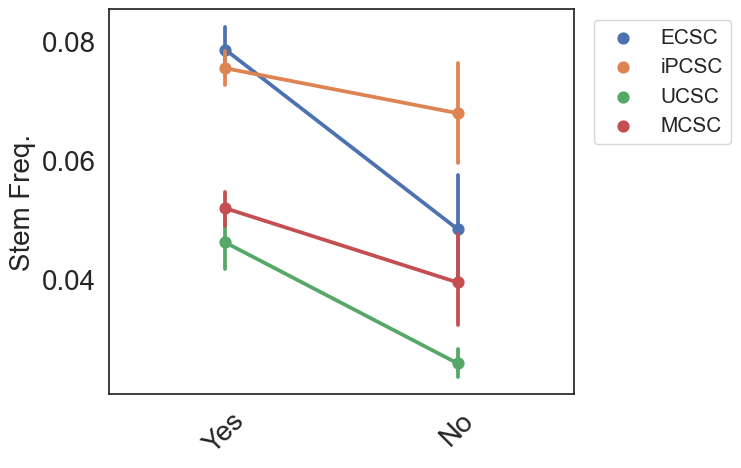

In [86]:
sns.set(rc={'figure.figsize':(6,5)})

sns.set_style('white')

sns.pointplot(data=data, x="PRIMARY_LYMPH_NODE_PRESENTATION_ASSESSMENT", y="stem", hue='predicted_label')
ax = plt.gca()
ax.tick_params(axis='y', labelsize=20)
ax.tick_params(axis='x', labelsize=20, rotation=45)

ax.set_xlabel('', fontsize=20)  
ax.set_ylabel('Stem Freq.', fontsize=20)
ax.legend(fontsize=15, bbox_to_anchor=(1.02, 1), loc='upper left')

# plt.savefig('point_stem_lymph.png', dpi=600, bbox_inches='tight')

In [ ]:
# 6.C,D,E R code
'''
library(ggpubr)
library(dplyr)

# response is the data generated above 6.C = data1, 6.D = data2, 6.E = data3
filtered_data <- subset(response, grepl("iPSC", predicted_label, ignore.case = TRUE)) # do it for each class

ggp <- ggpaired(filtered_data, x = "NEW_TUMOR_EVENT_AFTER_INITIAL_TREATMENT", y = "stem", facet.by = "predicted_label", ylab = "CSC frequency",
                color = "NEW_TUMOR_EVENT_AFTER_INITIAL_TREATMENT", width = 0.5, line.color = "gray", line.size = 0.3,
                palette = "npg")  # change x and color accordingly

# Modify text size
ggp +
  theme(axis.text.x = element_text(size = 15),  # Adjust x-axis tick label size
        axis.text.y = element_text(size = 15),  # Adjust y-axis tick label size
        axis.title.x = element_text(size = 15), # Adjust x-axis label size
        axis.title.y = element_text(size = 15)) # Adjust y-axis label size

ggsave("ipsc_response.png", height = 4, width = 4, dpi = 600)
'''

Fig - 7 (WGCNA module)

Fig - 8 (GSEA module)

Fig - 9.A

In [90]:
df = pd.read_csv('Data/Figure_Data/heatmap_marker_487.csv', index_col=(0))
df

,MCE,Scent,stem,predicted_label,HSD17B12,GPR19,TAF12,SOD1,RANBP1,POLH,...,NCL,TBC1D17,COMMD3,CSDE1,KIT,ZIC1,SMARCAD1,SF3A2,CNOT4,DDX5
TCGA-05-4244-01,0.865286,0.963758,0.018238,hESC,6.719889,6.121885,7.453840,6.822144,6.425043,7.081035,...,6.532695,6.307059,6.787057,7.016106,7.921779,0.918819,6.839166,6.033292,6.741056,7.319481
TCGA-05-4249-01,0.863655,0.962889,0.042426,hMSC,7.421726,4.001391,6.646446,6.368043,6.564961,6.620682,...,7.005502,6.943874,7.458150,6.905488,6.943176,0.000000,7.439928,6.735042,6.944585,7.470827
TCGA-05-4250-01,0.867993,0.965142,0.071180,hMSC,6.619132,5.227512,7.115241,6.601037,7.157746,6.396498,...,7.062259,5.816980,6.912547,6.610942,5.307671,6.138819,7.543685,6.362702,6.926744,7.083085
TCGA-05-4382-01,0.863094,0.962964,0.037569,hESC,7.682637,7.559896,7.339968,6.509005,7.135372,7.072178,...,7.222035,7.136155,7.795849,7.510328,6.067741,4.483726,6.491873,6.753639,7.149403,7.646653
TCGA-05-4384-01,0.862890,0.962012,0.010948,hMSC,6.394941,3.413158,6.639991,5.732907,5.267155,5.891994,...,5.935772,5.868914,5.888281,6.403323,9.782810,0.000000,6.271060,4.847690,6.026912,6.473917
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-61-2113-01,0.864652,0.963663,0.124652,iPSC,6.192926,7.475471,6.898450,5.324319,7.617468,7.328294,...,7.049469,8.023483,6.652207,6.905439,2.654445,8.272098,6.787546,7.045901,8.071202,7.198159
TCGA-OY-A56P-01,0.865035,0.963706,0.180374,iPSC,6.242655,6.474883,6.457464,6.457902,7.070233,7.128411,...,7.879807,7.024878,5.398966,8.686578,4.123714,9.720965,8.480507,7.529404,8.128333,6.960493
TCGA-OY-A56Q-01,0.864030,0.963554,0.178266,iPSC,5.549681,6.786572,6.358707,6.540452,6.813636,7.322873,...,7.832216,7.066143,5.112575,7.615700,3.323113,13.679571,7.570492,7.352283,7.828867,6.265276
TCGA-VG-A8LO-01,0.865939,0.964522,0.143781,iPSC,6.479940,6.542841,7.079906,6.930794,7.021408,7.547468,...,7.475574,7.563547,6.897690,7.428746,1.062747,1.689933,7.062697,7.330701,7.536058,6.376378


In [114]:
data = df.groupby('predicted_label')

name1 = []
len2 = []
for name, group in data:
    name1.append(name)
    group = group.iloc[:, [1] + list(range(4, group.shape[1]))]
    group = group.corr(method ='pearson')
    group = list(group.iloc[1:,0])
    len2.append(group)
print(name1)

['hESC', 'hMSC', 'hUSC', 'iPSC']


In [115]:
# list((df.iloc[:,4:]).columns)
pd.DataFrame(len2).shape, df.shape

((4, 458), (8786, 462))

In [116]:
mut = pd.DataFrame(len2)
mut = mut.fillna(0)
mut.index = name1
mut.columns = list((df.iloc[:,4:]).columns)
mut

,HSD17B12,GPR19,TAF12,SOD1,RANBP1,POLH,ETV4,CETN3,TCEA1,TRIM8,...,NCL,TBC1D17,COMMD3,CSDE1,KIT,ZIC1,SMARCAD1,SF3A2,CNOT4,DDX5
hESC,0.108234,0.368686,0.134387,-0.076457,0.601732,-0.003327,0.449096,0.120578,0.156811,-0.269118,...,0.425968,-0.251939,-0.012921,0.047760,-0.114602,-0.016647,0.146266,0.268496,0.012856,0.074407
hMSC,0.026820,0.429822,0.132942,0.125221,0.496522,-0.052972,0.234240,0.081579,0.194366,-0.191381,...,0.243027,-0.196246,0.152743,-0.109574,-0.343273,0.198341,0.014888,0.152349,-0.063215,-0.110152
hUSC,-0.234028,-0.179107,0.411736,-0.067134,0.475867,0.214435,0.292279,0.079723,0.151062,-0.252443,...,0.348374,-0.297635,0.301735,0.216395,-0.208423,-0.321860,-0.094864,0.273225,-0.232383,0.068416
iPSC,0.032742,0.429095,0.249227,-0.348917,0.586992,0.113718,0.375350,0.232535,0.248499,-0.221947,...,0.469826,-0.281529,0.050189,0.124304,-0.087684,-0.065043,0.245277,0.394315,0.108826,0.153829


[Text(1, 0.5, 'hUSC'),
 Text(1, 1.5, 'hMSC'),
 Text(1, 2.5, 'hESC'),
 Text(1, 3.5, 'iPSC')]

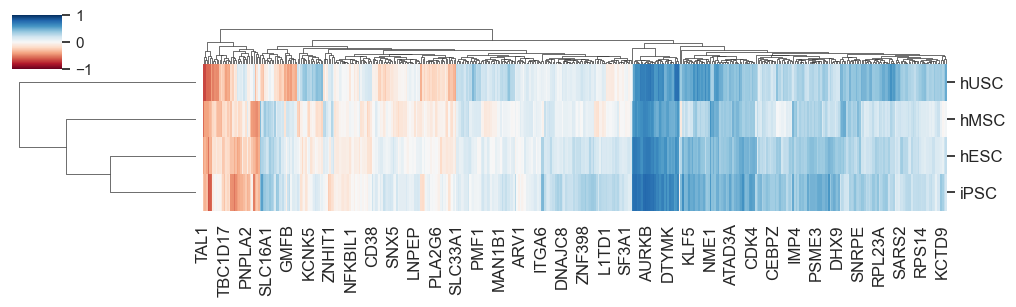

In [117]:
cluster = sns.clustermap(mut, annot=False, cmap = 'RdBu', vmin=-1, vmax=1, figsize=(10, 3),
               annot_kws={"size": 6}, cbar_kws={"shrink": 0.8})
cluster.ax_heatmap.set_xticklabels(cluster.ax_heatmap.get_xticklabels(), fontsize=12, rotation=90)
cluster.ax_heatmap.set_yticklabels(cluster.ax_heatmap.get_yticklabels(), fontsize=12, rotation=0)
# plt.savefig('scent_marker_heatmap.png', dpi=600, bbox_inches='tight')

Fig - 9.B

In [118]:
df = pd.read_csv('Data/Figure_Data/22_analysis.csv', index_col=(0))
df

,Cancer,predicted_label,ITH,MCE,Scent,T cells CD8,Monocytes,T cells CD4,NKT cells,B cells,...,KIRC,OV,LAML,GBM,CESC,CHOL,LIHC,BRCA,LGG,HNSC
TCGA-05-4244-01,LUAD,hESC,1.550568,0.865286,0.963758,0.000000,0.039980,0.000000,0.073005,0.000000,...,0.000000,0.066900,0.000000,0.000000,0.020913,0.017971,0.001756,0.026924,0.000000,0.062705
TCGA-05-4249-01,LUAD,hMSC,1.522665,0.863655,0.962889,0.006788,0.044550,0.000000,0.000000,0.000000,...,0.000000,0.077520,0.000000,0.000000,0.023272,0.000000,0.027158,0.038166,0.000000,0.083833
TCGA-05-4250-01,LUAD,hMSC,1.481596,0.867993,0.965142,0.005432,0.046202,0.000000,0.016369,0.000000,...,0.037647,0.073750,0.001643,0.008069,0.000000,0.004955,0.000000,0.004632,0.000000,0.055172
TCGA-05-4382-01,LUAD,hESC,1.861928,0.863094,0.962964,0.000000,0.073508,0.000000,0.003176,0.000000,...,0.002395,0.059701,0.000061,0.002624,0.054136,0.000000,0.012245,0.019079,0.000000,0.060875
TCGA-05-4384-01,LUAD,hMSC,1.335044,0.862890,0.962012,0.000000,0.052751,0.000000,0.000000,0.000000,...,0.000000,0.110010,0.000934,0.000000,0.021982,0.013282,0.074750,0.077159,0.000000,0.021030
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-61-2113-01,OV,iPSC,1.469182,0.864652,0.963663,0.000000,0.021256,0.000000,0.000953,0.000000,...,0.000000,0.258790,0.000000,0.000000,0.051753,0.000000,0.000778,0.000000,0.000000,0.099472
TCGA-OY-A56P-01,OV,iPSC,2.031723,0.865035,0.963706,0.000000,0.000000,0.051863,0.014616,0.000000,...,0.000000,0.225032,0.000000,0.004164,0.015711,0.000000,0.005041,0.000272,0.092499,0.072270
TCGA-OY-A56Q-01,OV,iPSC,2.026093,0.864030,0.963554,0.000000,0.000000,0.017332,0.000000,0.000000,...,0.000000,0.332592,0.003186,0.000000,0.000000,0.015688,0.003149,0.052760,0.138610,0.075669
TCGA-VG-A8LO-01,OV,iPSC,1.785248,0.865939,0.964522,0.000000,0.000000,0.006477,0.001433,0.002782,...,0.000000,0.460801,0.000000,0.000000,0.045749,0.000000,0.016104,0.018896,0.000000,0.087816


In [119]:
group = df.groupby('Cancer')
req = []
for i in df['Cancer'].unique():
    df = group.get_group(i)
    if i == 'LUAD' or 'LUSC':
        df = df.drop(['LUAD'], axis=1)
        df['Sum'] = (df.iloc[:,12:]).sum(axis=1)
        req.append(df)
    else:
        df = df.drop([i], axis=1)
        df['Sum'] = (df.iloc[:,12:]).sum(axis=1)
        req.append(df)

In [120]:
df = pd.concat(req, axis=0)
df

,Cancer,predicted_label,ITH,MCE,Scent,T cells CD8,Monocytes,T cells CD4,NKT cells,B cells,...,OV,LAML,GBM,CESC,CHOL,LIHC,BRCA,LGG,HNSC,Sum
TCGA-05-4244-01,LUAD,hESC,1.550568,0.865286,0.963758,0.000000,0.039980,0.000000,0.073005,0.000000,...,0.066900,0.000000,0.000000,0.020913,0.017971,0.001756,0.026924,0.000000,0.062705,0.586806
TCGA-05-4249-01,LUAD,hMSC,1.522665,0.863655,0.962889,0.006788,0.044550,0.000000,0.000000,0.000000,...,0.077520,0.000000,0.000000,0.023272,0.000000,0.027158,0.038166,0.000000,0.083833,0.674682
TCGA-05-4250-01,LUAD,hMSC,1.481596,0.867993,0.965142,0.005432,0.046202,0.000000,0.016369,0.000000,...,0.073750,0.001643,0.008069,0.000000,0.004955,0.000000,0.004632,0.000000,0.055172,0.779252
TCGA-05-4382-01,LUAD,hESC,1.861928,0.863094,0.962964,0.000000,0.073508,0.000000,0.003176,0.000000,...,0.059701,0.000061,0.002624,0.054136,0.000000,0.012245,0.019079,0.000000,0.060875,0.855963
TCGA-05-4384-01,LUAD,hMSC,1.335044,0.862890,0.962012,0.000000,0.052751,0.000000,0.000000,0.000000,...,0.110010,0.000934,0.000000,0.021982,0.013282,0.074750,0.077159,0.000000,0.021030,0.732963
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-61-2113-01,OV,iPSC,1.469182,0.864652,0.963663,0.000000,0.021256,0.000000,0.000953,0.000000,...,0.258790,0.000000,0.000000,0.051753,0.000000,0.000778,0.000000,0.000000,0.099472,0.853139
TCGA-OY-A56P-01,OV,iPSC,2.031723,0.865035,0.963706,0.000000,0.000000,0.051863,0.014616,0.000000,...,0.225032,0.000000,0.004164,0.015711,0.000000,0.005041,0.000272,0.092499,0.072270,0.753147
TCGA-OY-A56Q-01,OV,iPSC,2.026093,0.864030,0.963554,0.000000,0.000000,0.017332,0.000000,0.000000,...,0.332592,0.003186,0.000000,0.000000,0.015688,0.003149,0.052760,0.138610,0.075669,0.797912
TCGA-VG-A8LO-01,OV,iPSC,1.785248,0.865939,0.964522,0.000000,0.000000,0.006477,0.001433,0.002782,...,0.460801,0.000000,0.000000,0.045749,0.000000,0.016104,0.018896,0.000000,0.087816,0.843747


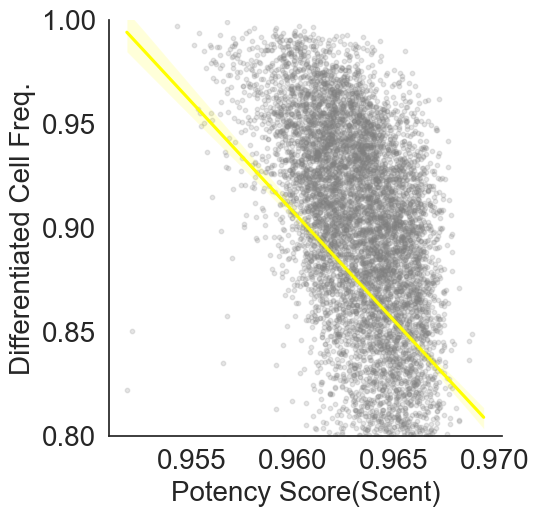

In [121]:
sns.set_style('white')

sns.lmplot(x ='Scent', y ='Sum', data = df, scatter=True,
          scatter_kws={'color': 'gray', 's': 10, 'alpha': 0.2}, line_kws={'color': 'yellow'},
           ci=95)
ax = plt.gca()
plt.ylim(0.8, 1.0)
ax.tick_params(axis='y', labelsize=20)
ax.tick_params(axis='x', labelsize=20)
ax.set_ylabel('Differentiated Cell Freq.', fontsize=20)
ax.set_xlabel('Potency Score(Scent)', fontsize=20)
# plt.savefig('reg_scent_sum.png', dpi=600, bbox_inches='tight')
plt.show()

Fig - 9.C, D

In [122]:
df = pd.read_csv('Data/Figure_Data/22_analysis.csv', index_col=(0))
df

,Cancer,predicted_label,ITH,MCE,Scent,T cells CD8,Monocytes,T cells CD4,NKT cells,B cells,...,KIRC,OV,LAML,GBM,CESC,CHOL,LIHC,BRCA,LGG,HNSC
TCGA-05-4244-01,LUAD,hESC,1.550568,0.865286,0.963758,0.000000,0.039980,0.000000,0.073005,0.000000,...,0.000000,0.066900,0.000000,0.000000,0.020913,0.017971,0.001756,0.026924,0.000000,0.062705
TCGA-05-4249-01,LUAD,hMSC,1.522665,0.863655,0.962889,0.006788,0.044550,0.000000,0.000000,0.000000,...,0.000000,0.077520,0.000000,0.000000,0.023272,0.000000,0.027158,0.038166,0.000000,0.083833
TCGA-05-4250-01,LUAD,hMSC,1.481596,0.867993,0.965142,0.005432,0.046202,0.000000,0.016369,0.000000,...,0.037647,0.073750,0.001643,0.008069,0.000000,0.004955,0.000000,0.004632,0.000000,0.055172
TCGA-05-4382-01,LUAD,hESC,1.861928,0.863094,0.962964,0.000000,0.073508,0.000000,0.003176,0.000000,...,0.002395,0.059701,0.000061,0.002624,0.054136,0.000000,0.012245,0.019079,0.000000,0.060875
TCGA-05-4384-01,LUAD,hMSC,1.335044,0.862890,0.962012,0.000000,0.052751,0.000000,0.000000,0.000000,...,0.000000,0.110010,0.000934,0.000000,0.021982,0.013282,0.074750,0.077159,0.000000,0.021030
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-61-2113-01,OV,iPSC,1.469182,0.864652,0.963663,0.000000,0.021256,0.000000,0.000953,0.000000,...,0.000000,0.258790,0.000000,0.000000,0.051753,0.000000,0.000778,0.000000,0.000000,0.099472
TCGA-OY-A56P-01,OV,iPSC,2.031723,0.865035,0.963706,0.000000,0.000000,0.051863,0.014616,0.000000,...,0.000000,0.225032,0.000000,0.004164,0.015711,0.000000,0.005041,0.000272,0.092499,0.072270
TCGA-OY-A56Q-01,OV,iPSC,2.026093,0.864030,0.963554,0.000000,0.000000,0.017332,0.000000,0.000000,...,0.000000,0.332592,0.003186,0.000000,0.000000,0.015688,0.003149,0.052760,0.138610,0.075669
TCGA-VG-A8LO-01,OV,iPSC,1.785248,0.865939,0.964522,0.000000,0.000000,0.006477,0.001433,0.002782,...,0.000000,0.460801,0.000000,0.000000,0.045749,0.000000,0.016104,0.018896,0.000000,0.087816


/opt/homebrew/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning:

is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead

/opt/homebrew/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning:

is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead

/opt/homebrew/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning:

is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead

/opt/homebrew/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning:

is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead



Text(0, 0.5, 'Potency Score')

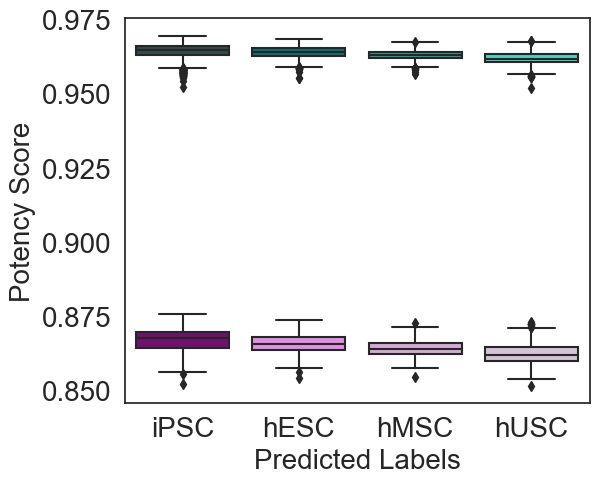

In [123]:

custom_palette = {
    'iPSC': 'darkslategrey',
    'hESC': 'teal',
    'hMSC': 'lightseagreen',
    'hUSC': 'turquoise'
}

custom_palette1 = {
    'iPSC': 'purple',
    'hESC': 'violet',
    'hMSC': 'plum',
    'hUSC': 'thistle'
}


fig, ax = plt.subplots()
sns.boxplot(data=df,
              x='predicted_label', y='MCE',
             order = ['iPSC', 'hESC', 'hMSC', 'hUSC'],
              palette=custom_palette1, ax = ax)

sns.boxplot(data=df,
              x='predicted_label', y='Scent',
             order = ['iPSC', 'hESC', 'hMSC', 'hUSC'],
              palette=custom_palette, ax = ax)

ax.tick_params(axis='y', labelsize=20)
ax.tick_params(axis='x', labelsize=20)

ax.set_xlabel('Predicted Labels', fontsize=20)  
ax.set_ylabel('Potency Score', fontsize=20)  


# plt.savefig('box_mce_scent.png', dpi=600, bbox_inches='tight')

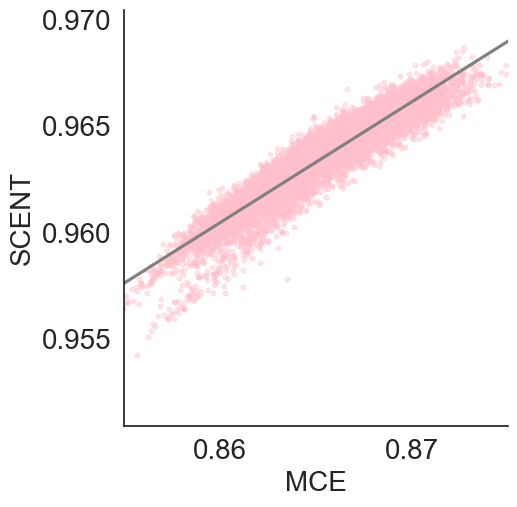

In [124]:
sns.set_style('white')

sns.lmplot(x ='MCE', y ='Scent', data = df, scatter=True,
          scatter_kws={'color': 'pink', 's': 10, 'alpha': 0.4}, line_kws={'color': 'gray'},
           ci=95)

ax = plt.gca()
# plt.ylim(0.95, 0.97)
plt.xlim(0.855, 0.875)
ax.tick_params(axis='y', labelsize=20)
ax.tick_params(axis='x', labelsize=20)
ax.set_ylabel('SCENT', fontsize=20)
ax.set_xlabel('MCE', fontsize=20)
# plt.savefig('reg_scent_mce.png', dpi=600, bbox_inches='tight')
plt.show()

Fig - 10 A-F

In [125]:
df = pd.read_csv('Data/Figure_Data/heatmap_marker.csv', index_col=(0))
df

,stem,predicted_label,MSI1,CD151,CXCR1,CD44,BMI1,ZFP42,PODXL,ALCAM,...,CD38,SALL4,CD34,PROM1,EPCAM,HAVCR2,CXCR4,CD27,ALDH1A1,MYC
TCGA-05-4244-01,0.018238,hESC,1.175729,7.168724,4.951544,6.269922,6.326472,0.000000,6.225009,6.888777,...,5.445356,6.112325,5.680226,5.491075,8.068577,7.630223,7.188120,5.336913,4.368125,6.460339
TCGA-05-4249-01,0.042426,hMSC,1.591924,7.091456,6.782386,5.918494,7.661966,5.947809,6.410943,7.920213,...,6.562919,9.185499,6.298402,5.537137,7.953634,7.708588,6.094493,7.478788,4.610389,5.827512
TCGA-05-4250-01,0.071180,hMSC,2.095446,7.595851,6.285337,6.989833,6.834956,1.960408,6.131735,8.070916,...,6.968587,5.727615,5.831549,1.834343,8.089159,7.965398,7.478342,7.001070,4.623058,8.267017
TCGA-05-4382-01,0.037569,hESC,4.868053,7.521764,7.985143,7.402737,8.091323,0.000000,6.574074,9.247061,...,7.899481,7.940184,6.864849,7.633641,8.200983,9.004247,8.414191,9.165889,5.766936,5.539267
TCGA-05-4384-01,0.010948,hMSC,5.791601,6.268869,6.916145,6.022907,6.027947,6.866275,6.015335,8.002819,...,6.606448,4.533511,6.910240,1.004544,5.989520,6.298680,5.528014,5.218781,4.581300,4.823540
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-61-2113-01,0.124652,iPSC,8.515220,6.373429,4.616281,5.145583,7.369399,1.960408,8.100854,6.048950,...,6.753102,9.354679,6.132726,1.384102,7.155512,7.090321,6.537068,5.497744,3.591643,6.651006
TCGA-OY-A56P-01,0.180374,iPSC,10.635447,6.664105,4.484648,4.376043,6.773679,11.106229,11.358203,4.577371,...,3.619979,9.408141,5.069211,8.883421,7.924467,3.628347,7.643681,3.517612,1.609940,8.470983
TCGA-OY-A56Q-01,0.178266,iPSC,10.583123,6.358636,0.000000,2.791327,6.723348,7.708765,10.573530,2.558519,...,2.065476,3.692857,5.631167,5.438480,7.955507,3.167865,9.630419,3.325549,2.282932,7.500493
TCGA-VG-A8LO-01,0.143781,iPSC,9.214372,6.142571,3.790015,2.360418,7.230617,0.000000,7.957731,6.455375,...,4.244573,10.294103,4.668427,5.629477,7.586746,4.287938,7.836162,3.596412,3.055502,7.726065


In [126]:
df2 = pd.read_csv('Data/Figure_Data/22_analysis.csv', index_col=(0))
df2 = df2[['Monocytes']]  # change to different immune cells accordingly
df2

,Monocytes
TCGA-05-4244-01,0.039980
TCGA-05-4249-01,0.044550
TCGA-05-4250-01,0.046202
TCGA-05-4382-01,0.073508
TCGA-05-4384-01,0.052751
...,...
TCGA-61-2113-01,0.021256
TCGA-OY-A56P-01,0.000000
TCGA-OY-A56Q-01,0.000000
TCGA-VG-A8LO-01,0.000000


In [127]:
req = pd.concat([df, df2], axis=1)
req

,stem,predicted_label,MSI1,CD151,CXCR1,CD44,BMI1,ZFP42,PODXL,ALCAM,...,SALL4,CD34,PROM1,EPCAM,HAVCR2,CXCR4,CD27,ALDH1A1,MYC,Monocytes
TCGA-05-4244-01,0.018238,hESC,1.175729,7.168724,4.951544,6.269922,6.326472,0.000000,6.225009,6.888777,...,6.112325,5.680226,5.491075,8.068577,7.630223,7.188120,5.336913,4.368125,6.460339,0.039980
TCGA-05-4249-01,0.042426,hMSC,1.591924,7.091456,6.782386,5.918494,7.661966,5.947809,6.410943,7.920213,...,9.185499,6.298402,5.537137,7.953634,7.708588,6.094493,7.478788,4.610389,5.827512,0.044550
TCGA-05-4250-01,0.071180,hMSC,2.095446,7.595851,6.285337,6.989833,6.834956,1.960408,6.131735,8.070916,...,5.727615,5.831549,1.834343,8.089159,7.965398,7.478342,7.001070,4.623058,8.267017,0.046202
TCGA-05-4382-01,0.037569,hESC,4.868053,7.521764,7.985143,7.402737,8.091323,0.000000,6.574074,9.247061,...,7.940184,6.864849,7.633641,8.200983,9.004247,8.414191,9.165889,5.766936,5.539267,0.073508
TCGA-05-4384-01,0.010948,hMSC,5.791601,6.268869,6.916145,6.022907,6.027947,6.866275,6.015335,8.002819,...,4.533511,6.910240,1.004544,5.989520,6.298680,5.528014,5.218781,4.581300,4.823540,0.052751
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-61-2113-01,0.124652,iPSC,8.515220,6.373429,4.616281,5.145583,7.369399,1.960408,8.100854,6.048950,...,9.354679,6.132726,1.384102,7.155512,7.090321,6.537068,5.497744,3.591643,6.651006,0.021256
TCGA-OY-A56P-01,0.180374,iPSC,10.635447,6.664105,4.484648,4.376043,6.773679,11.106229,11.358203,4.577371,...,9.408141,5.069211,8.883421,7.924467,3.628347,7.643681,3.517612,1.609940,8.470983,0.000000
TCGA-OY-A56Q-01,0.178266,iPSC,10.583123,6.358636,0.000000,2.791327,6.723348,7.708765,10.573530,2.558519,...,3.692857,5.631167,5.438480,7.955507,3.167865,9.630419,3.325549,2.282932,7.500493,0.000000
TCGA-VG-A8LO-01,0.143781,iPSC,9.214372,6.142571,3.790015,2.360418,7.230617,0.000000,7.957731,6.455375,...,10.294103,4.668427,5.629477,7.586746,4.287938,7.836162,3.596412,3.055502,7.726065,0.000000


In [128]:
data = req.groupby('predicted_label')

name1 = []
len2 = []
for name, group in data:
    name1.append(name)
    group = group.iloc[:,2:]
    group = group.corr(method ='pearson')
    group = list(group.iloc[:-1,-1])
    len2.append(group)
print(name1)

['hESC', 'hMSC', 'hUSC', 'iPSC']


In [129]:
mut = pd.DataFrame(len2)
mut = mut.fillna(0)
mut.index = name1
mut.columns = list((req.iloc[:,2:-1]).columns)
mut

,MSI1,CD151,CXCR1,CD44,BMI1,ZFP42,PODXL,ALCAM,ENG,CEACAM6,...,CD38,SALL4,CD34,PROM1,EPCAM,HAVCR2,CXCR4,CD27,ALDH1A1,MYC
hESC,-0.228534,-0.085964,0.292006,0.192318,0.099941,0.101510,0.142851,0.098217,0.362461,0.030529,...,0.294356,-0.111742,0.315591,0.040316,-0.149390,0.534566,0.433839,0.298199,0.077408,-0.078116
hMSC,-0.308689,-0.390935,0.271290,0.061545,-0.005368,-0.039180,-0.270384,-0.093239,-0.091153,0.018654,...,0.284177,-0.154877,0.120483,0.142140,-0.309297,0.308776,0.296207,0.064987,-0.157604,0.027674
hUSC,-0.314339,-0.162683,0.309075,0.148839,-0.141371,0.051298,-0.235891,-0.135406,0.019260,0.086909,...,0.183254,-0.156808,-0.031915,0.061865,-0.104767,0.259960,0.313788,0.121178,-0.093585,-0.054708
iPSC,-0.131702,-0.125644,0.194783,0.048098,0.104130,0.008390,0.085176,0.073229,0.223988,0.018369,...,0.299918,-0.032165,0.281212,0.133615,-0.043161,0.453973,0.370456,0.249535,0.001403,-0.040550


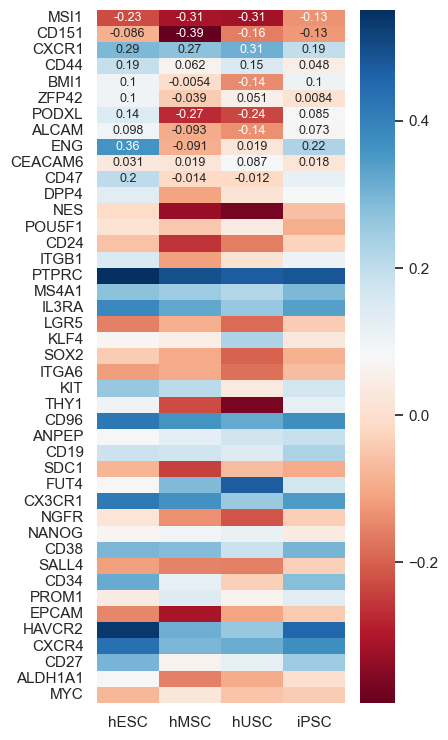

In [130]:
plt.figure(figsize=(4, 9))
sns.heatmap(mut.T, annot=True, cmap = 'RdBu', annot_kws={"size": 9})
plt.show()